In [531]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 机器学习工具
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 忽略不必要的警告
warnings.filterwarnings('ignore')

print("库导入,准备好进行数据加载。")

库导入,准备好进行数据加载。


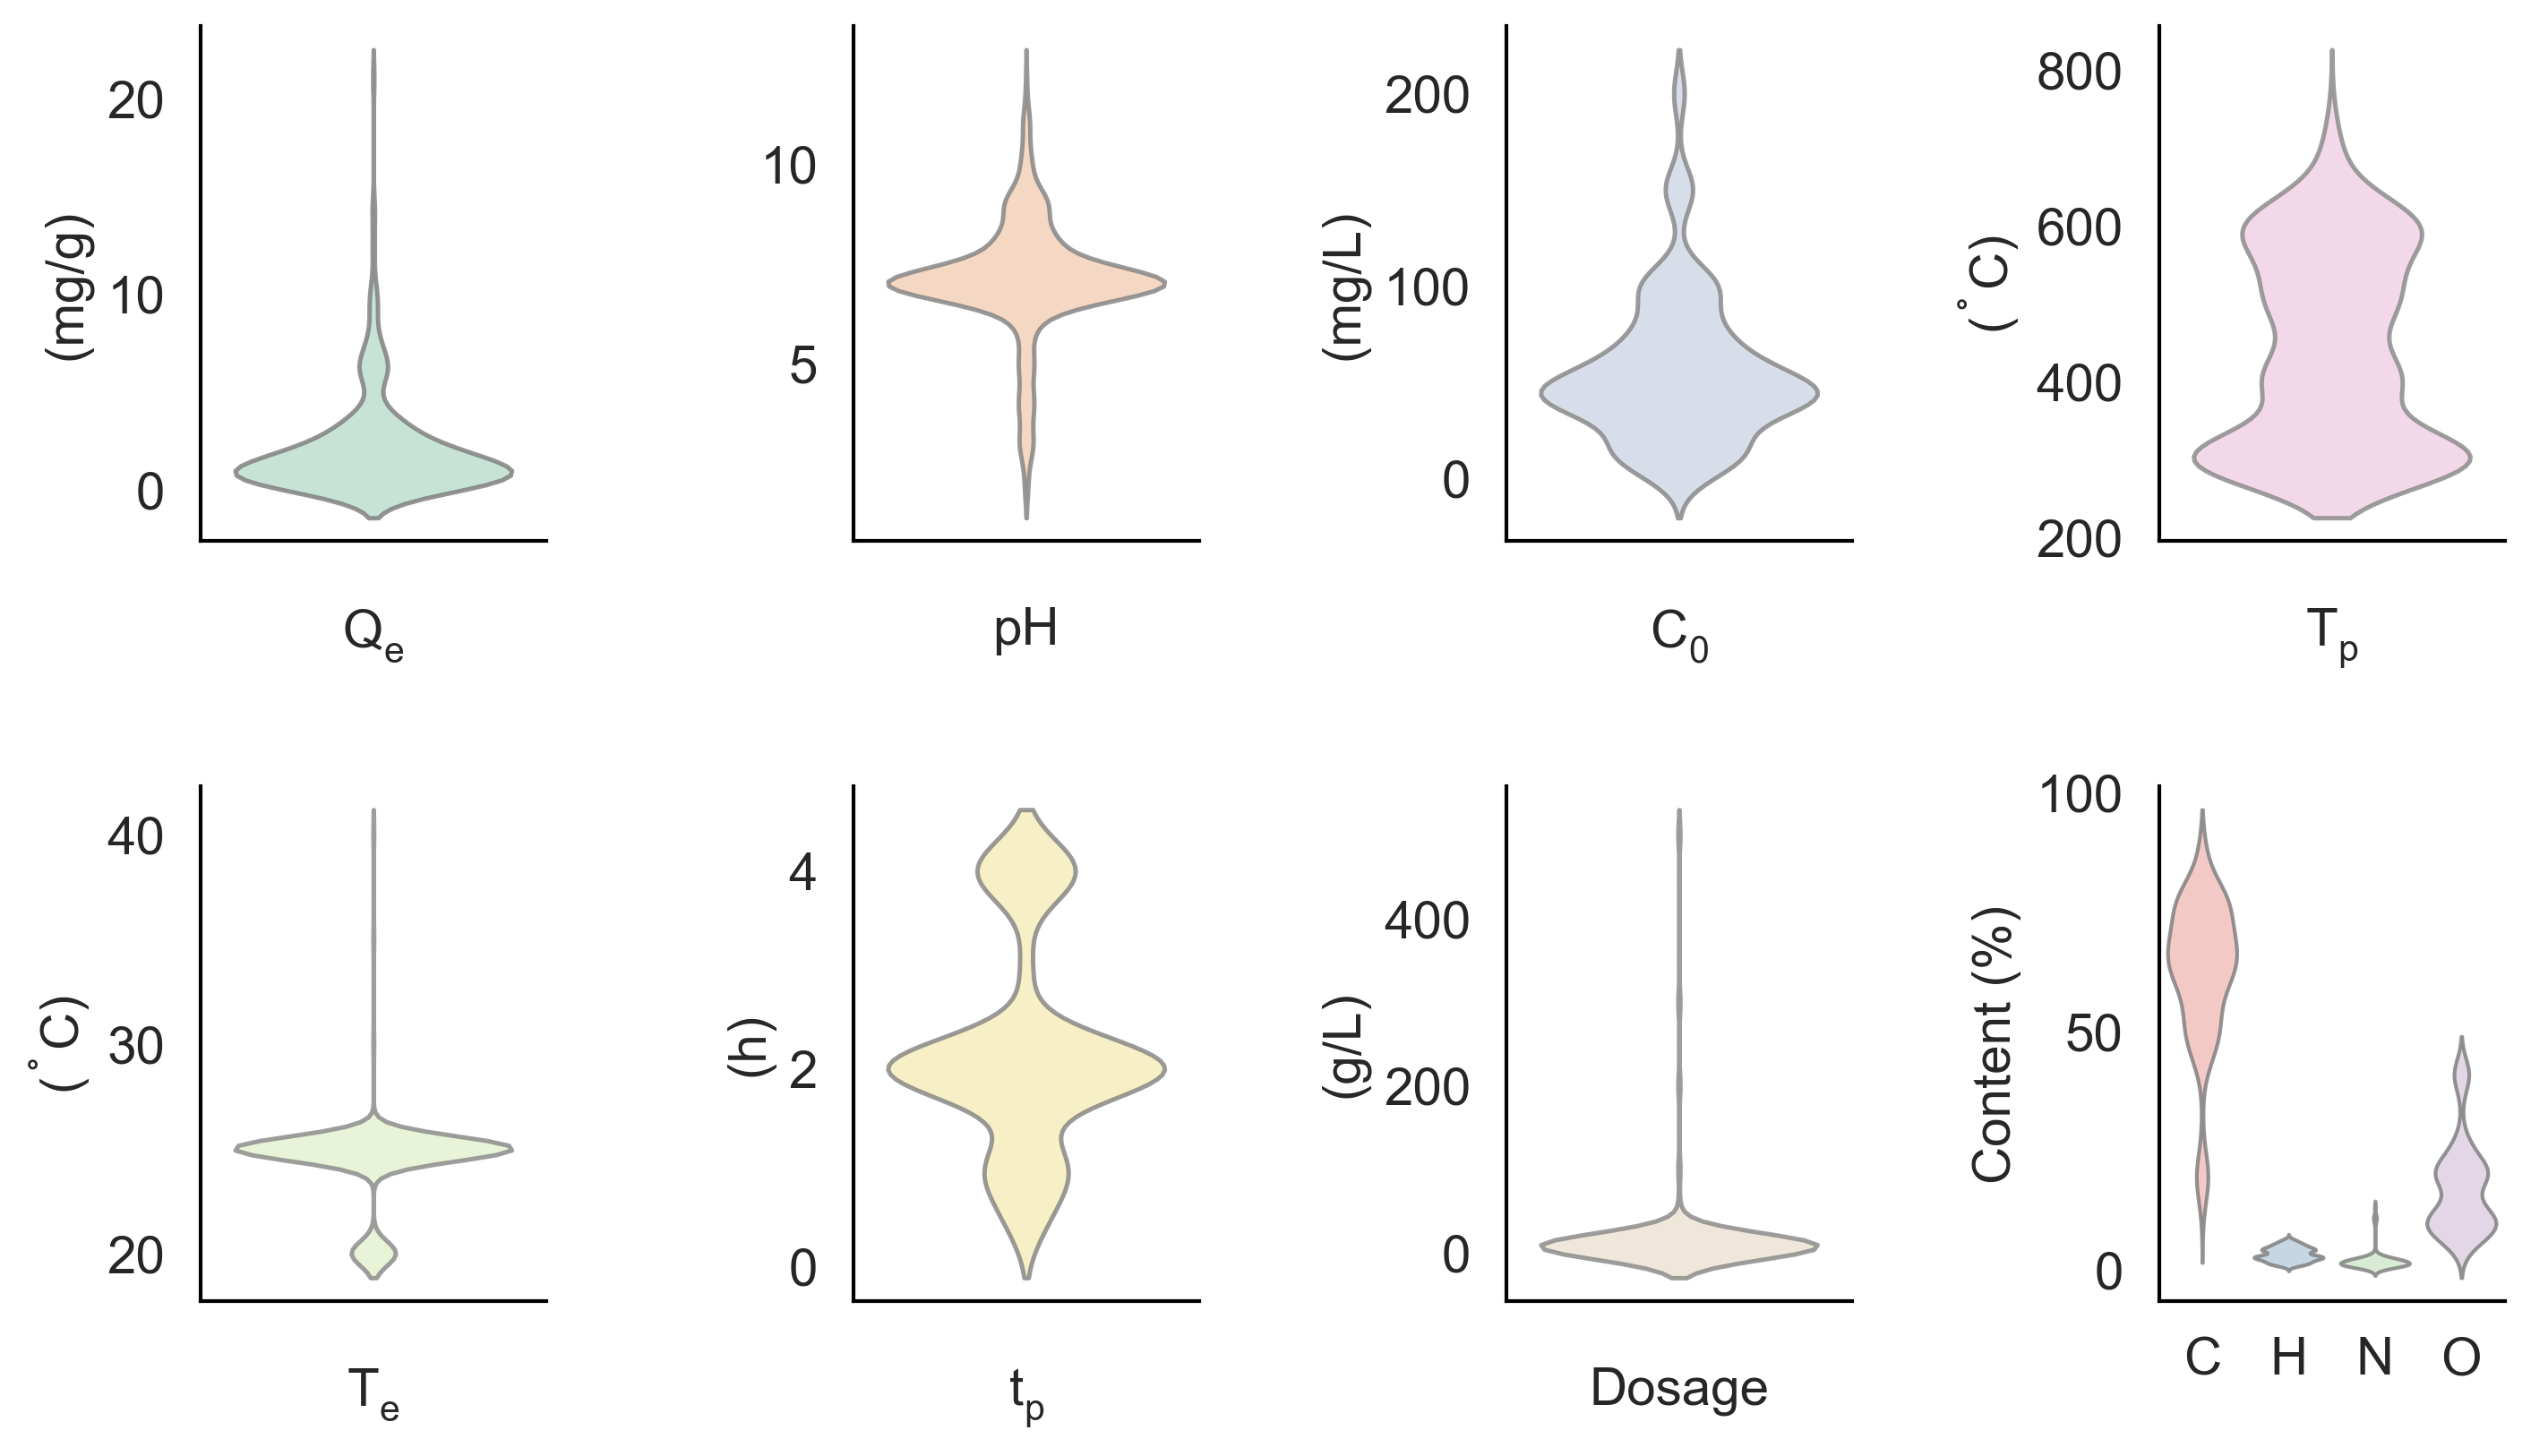

In [532]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# 1. 环境初始化：严格匹配五号字 (14 pt)
# ============================================================
%matplotlib inline
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 300,
    "axes.unicode_minus": False,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.0,         # 配合五号字，轴线粗细微调为1.0
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    # 全局字体设置
    "font.size": 14,             # 标准五号字
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})
sns.set_style("white")

# ============================================================
# 2. 数据导入与变量修正 (保持原逻辑不变)
# ============================================================
file_path = 'Adsorption.xlsx'
if os.path.exists(file_path):
    df_raw = pd.read_excel(file_path)
    rename_dict = {
        'Pyrolysis temp(°C)': 'T_pyroly', 'Temp(°C)': 'T_exp', 'C0(mg/L)': 'C_0',
        'pH': 'pH', 'Dosage(g/L)': 'Dosage', 'Time(h)': 't_p', 'Qe(mg/g)': 'Q_e',
        'C': 'C', 'H': 'H', 'N': 'N', 'O': 'O'
    }
    df_numeric = df_raw.rename(columns=rename_dict).apply(pd.to_numeric, errors='coerce')

# ============================================================
# 3. 执行绘图 (调整 figsize 以适应五号字排版)
# ============================================================
if 'df_numeric' in locals():
    plot_tasks = [
        'Q_e', 'pH', 'C_0', 'T_pyroly',
        'T_exp', 't_p', 'Dosage', ['C', 'H', 'N', 'O']
    ]

    label_map = {
        'Q_e': '$Q_{\mathregular{e}}$', 'C_0': '$C_{\mathregular{0}}$',
        'T_pyroly': '$T_{\mathregular{p}}$', 'T_exp': '$T_{\mathregular{e}}$',
        'pH': 'pH', 'Dosage': 'Dosage', 't_p': '$t_{\mathregular{p}}$',
        'C': 'C', 'H': 'H', 'N': 'N', 'O': 'O'
    }
    unit_map = {
        'Q_e': '(mg/g)', 'C_0': '(mg/L)', 'T_pyroly': '($^\circ$C)',
        'T_exp': '($^\circ$C)', 'pH': '', 'Dosage': '(g/L)',
        't_p': '(h)', 'C': '(%)', 'H': '(%)', 'N': '(%)', 'O': '(%)'
    }

    # 调整 figsize 为 (10, 6) 左右，这样在 PDF 中文字大小与五号字最接近
    fig, axes = plt.subplots(2, 4, figsize=(10, 6))
    axes = axes.flatten()

    for i, col in enumerate(plot_tasks):
        ax = axes[i]
        ax.grid(False)

        if isinstance(col, list):  # 元素组成 (C, H, N, O)
            sns.violinplot(data=df_numeric[col].dropna(how='all'), ax=ax,
                           palette="Pastel1", inner=None, alpha=0.8, linewidth=1.0)
            ax.set_xticklabels([label_map.get(c, c) for c in col], fontsize=14)
            ax.set_ylabel('Content (%)', fontsize=14)
            ax.set_xlabel("", fontsize=0)
        else:
            # 独立物理量
            sns.violinplot(y=df_numeric[col].dropna(), ax=ax,
                           color=sns.color_palette("Pastel2")[i % 8],
                           inner=None, alpha=0.8, linewidth=1.2)
            ax.set_xlabel(label_map.get(col, col), fontsize=14, labelpad=8)
            ax.set_ylabel(unit_map.get(col, '').strip(), fontsize=14)
            ax.set_xticklabels([])

        # ============================================================
        # 强制统一坐标轴
        # ============================================================
        ax.tick_params(axis='y', labelsize=14)
        sns.despine(ax=ax, top=True, right=True)

        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(1.0)
        ax.spines['left'].set_color('black')

        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_linewidth(1.0)
        ax.spines['bottom'].set_color('black')

    plt.tight_layout(pad=2.0)
    # plt.savefig("Violin_Plot_5_Standard.pdf", format='pdf', bbox_inches='tight')
    plt.show()

# 皮尔逊相关矩阵分析

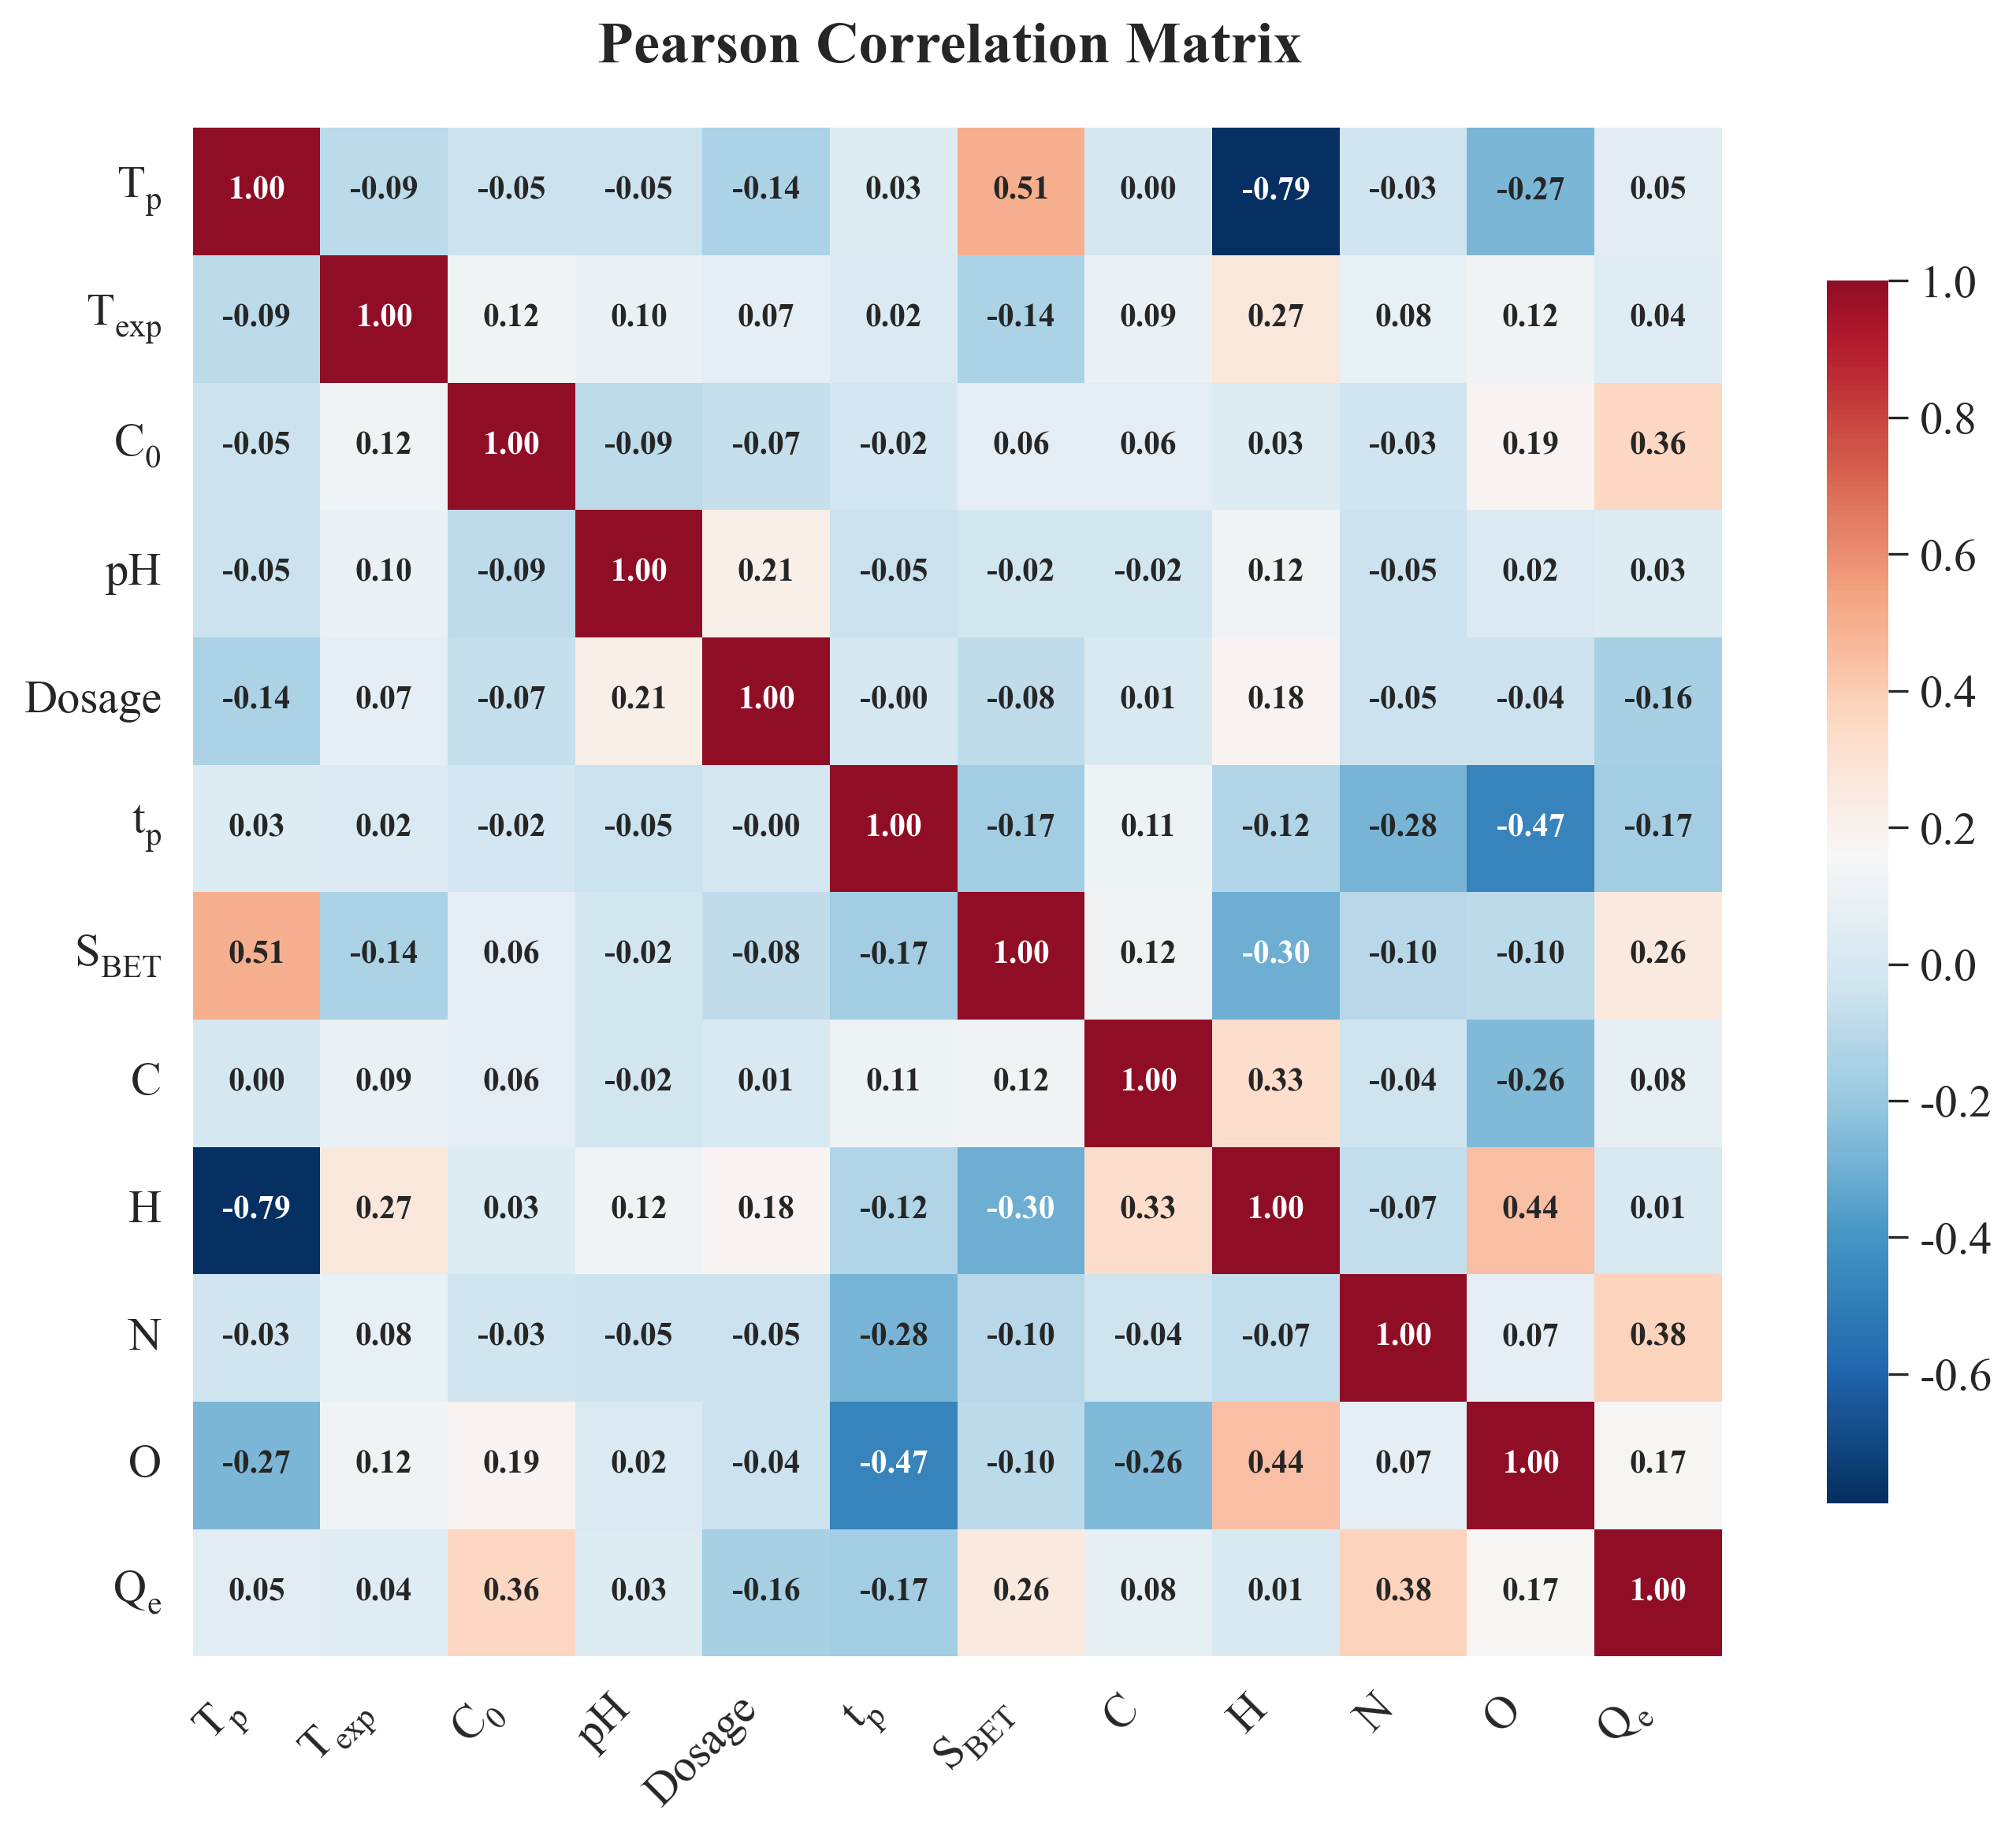


                               Pearson Correlation Matrix                                 
                         $\mathregular{T_{p}}$  $\mathregular{T_{exp}}$  $\mathregular{C_0}$      pH  Dosage  $\mathregular{t_{p}}$  $\mathregular{S_{BET}}$       C       H       N       O  $\mathregular{Q_e}$
$\mathregular{T_{p}}$                   1.0000                  -0.0947              -0.0470 -0.0453 -0.1434                 0.0298                   0.5092  0.0001 -0.7897 -0.0277 -0.2665               0.0531
$\mathregular{T_{exp}}$                -0.0947                   1.0000               0.1175  0.0963  0.0651                 0.0240                  -0.1395  0.0923  0.2706  0.0806  0.1215               0.0427
$\mathregular{C_0}$                    -0.0470                   0.1175               1.0000 -0.0855 -0.0690                -0.0205                   0.0564  0.0564  0.0337 -0.0280  0.1880               0.3603
pH                                     -0.0453                   0.0

In [528]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --------------------------
# 1. 数据加载与数值化
# --------------------------
df = pd.read_excel('Adsorption.xlsx')
# 将数据转换为数值型，非数值内容变为 NaN
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# --------------------------
# 2. 标签清洗与 LaTeX 格式化
# --------------------------
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['font.family'] = 'Times New Roman'

def clean_and_format(name):
    n_lower = name.lower()
    if 'c0' in n_lower:
        return r"$\mathregular{C_0}$"
    if 'qe' in n_lower:
        return r"$\mathregular{Q_e}$"
    if 'surface' in n_lower or 'sbet' in n_lower:
        return r"$\mathregular{S_{BET}}$"
    if 'pyroly' in n_lower and 'time' not in n_lower:
        return r"$\mathregular{T_{p}}$"
    if 'exp' in n_lower or ('temp' in n_lower and 'pyroly' not in n_lower):
        return r"$\mathregular{T_{exp}}$"
    if 'dosage' in n_lower:
        return "Dosage"
    if 'time' in n_lower:
        return r"$\mathregular{t_{p}}$"
    if 'ph' in n_lower:
        return "pH"
    if n_lower in ['c', 'h', 'n', 'o']:
        return n_lower.upper()

    return re.sub(r'\(.*?\)|（.*?）', '', name).strip()

# 应用重命名并计算相关性
rename_dict = {col: clean_and_format(col) for col in df_numeric.columns}
plot_df = df_numeric.rename(columns=rename_dict)
corr_matrix = plot_df.corr() # 此时计算的是原始数据的 Pearson 相关系数

# --------------------------
# 3. 绘图 (保持原有格式)
# --------------------------
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="RdBu_r",
            fmt=".2f",
            square=True,
            center=0.16,
            annot_kws={"size": 10, "weight": "bold"},
            cbar_kws={"shrink": .8},
            linewidths=0)

plt.title("Pearson Correlation Matrix ", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --------------------------
# 4. 控制台数值矩阵打印
# --------------------------
print("\n" + "="*90)
print(f"{'Pearson Correlation Matrix ':^90}")
print("="*90)

with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', 1000,
                       'display.precision', 2):
    print(corr_matrix)

print("="*90)

qe_label = r"$\mathregular{Q_e}$"
if qe_label in corr_matrix.columns:
    print(f"\n[Correlation with {qe_label} (No Imputation)]:")
    print(corr_matrix[qe_label].sort_values(ascending=False))

# knn填充和Z-score标准化

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import os

# ============================================================
# 0. 数据读取与变量准备
# ============================================================
file_path = 'Adsorption.xlsx'
if os.path.exists(file_path):
    df_raw = pd.read_excel(file_path)

    # 统一列名映射
    rename_dict = {
        'Pyrolysis temp(°C)': 'T_pyroly', 'Temp(°C)': 'T_exp', 'C0(mg/L)': 'C_0',
        'pH': 'pH', 'Dosage(g/L)': 'Dosage', 'Time(h)': 't_p', 'Qe(mg/g)': 'Q_e',
        'C': 'C', 'H': 'H', 'N': 'N', 'O': 'O'
    }

    # 将重命名后的数据转换为纯数值型，作为 KNN 的输入源 (df_numeric_pre)
    # 其余缺失值仍为 NaN
    df_numeric_pre = df_raw.rename(columns=rename_dict).apply(pd.to_numeric, errors='coerce')

    # ============================================================
    # 1. 数据填补 (KNN)
    # ============================================================
    # 对除 pH=7 以外的其余缺失值进行邻域填补
    imputer = KNNImputer(n_neighbors=5)
    df_filled_array = imputer.fit_transform(df_numeric_pre)
    df_filled = pd.DataFrame(df_filled_array, columns=df_numeric_pre.columns)

    # ============================================================
    # 2. Z-Score 标准化
    # ============================================================
    target_col = 'Q_e'
    # 提取特征 (X) 和 目标变量 (y)
    X = df_filled.drop(columns=[target_col])
    y = df_filled[target_col]

    scaler = StandardScaler()
    X_scaled_array = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

    # 合并标准化后的特征与原始目标变量 (Q_e 不进行标准化，保持 mg/g 单位)
    df_final_table = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

    # ============================================================
    # 3. 输出与导出
    # ============================================================
    print("\n" + "="*80)
    print(f"{'Processed Dataset (KNN + Z-Score) - Total: 425 Samples':^80}")
    print("="*80)

    pd.set_option('display.max_rows', 10)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.4f}'.format)

    print(df_final_table)

    print("-" * 80)
    print(f"Dataset Shape: {df_final_table.shape}")
    print(f"Missing values check: {df_final_table.isnull().sum().sum()}")
    print("="*80)

    # 导出结果
    df_final_table.to_excel('Processed_Adsorption_Data.xlsx', index=False)
    print("Processing complete. Final data saved to 'Processed_Adsorption_Data.xlsx'.")


             Processed Dataset (KNN + Z-Score) - Total: 425 Samples             
     T_pyroly   T_exp     C_0      pH  Dosage     t_p  Surface Area (m2/g)       C       H       N      O    Q_e
0      0.8807  0.3113 -0.1402 -0.6318 -0.2958 -0.1691               1.9207  0.6858 -0.8821 -0.8357 0.1314 3.3000
1      0.8807  0.3113 -0.1402 -0.6318 -0.2860 -0.1691               1.9207  0.6858 -0.8821 -0.8357 0.1314 6.4000
2      0.8807  0.3113 -0.1402 -0.6318 -0.2664 -0.1691               1.9207  0.6858 -0.8821 -0.8357 0.1314 2.7000
3      0.8807  0.3113 -0.1402 -0.6318 -0.2076 -0.1691               1.9207  0.6858 -0.8821 -0.8357 0.1314 2.3000
4     -1.0914  0.3113  1.1721 -0.0670 -0.2664 -1.1274              -0.4481 -0.1289  0.9899 -0.1240 1.7523 1.1000
..        ...     ...     ...     ...     ...     ...                  ...     ...     ...     ...    ...    ...
420   -1.0914 -2.2333 -1.1900  0.6389 -0.1095 -1.1274              -0.4632  0.0111  1.4579 -0.5036 0.3464 0.7260
421   -1.0914 

In [4]:
#数据读取
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ============================================================
# 1. 数据加载与对数变换
# ============================================================
# 读取已处理数据
df_final = pd.read_excel('Processed_Adsorption_Data.xlsx')

target_col = 'Q_e'
X = df_final.drop(columns=[target_col])
y_raw = df_final[target_col]

# 执行对数变换
y_log = np.log1p(y_raw)

# 核心：划分数据集 (固定 random_state=42 保证后续模型对比的公平性)
# 产生的 X_train, X_test, y_train_log, y_test_log 将作为全局变量供所有模型使用
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"✅ 数据准备完成！")
print(f"训练集样本量: {len(X_train)}，测试集样本量: {len(X_test)}")
print(f"特征维度: {X_train.shape[1]}")

✅ 数据准备完成！
训练集样本量: 340，测试集样本量: 85
特征维度: 11


In [5]:
import optuna
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_score
import sklearn
from sklearn import set_config

# 将显示模式从 'diagram' (交互框) 切换为 'text' (纯文本)
set_config(display='text')
# ============================================================
# 2. 贝叶斯优化定义 (ETR)
def objective_etr(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 1000), # 增加树的数量以提升精度
        # 允许树稍微长深一点，从之前的 12 放宽到 15-25
        'max_depth': trial.suggest_int('max_depth', 12, 25),
        # 限制分裂条件，确保每个分支都有实际意义
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 6),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 3), # 稍微减小叶片限制
        'max_features': trial.suggest_float('max_features', 0.4, 0.8), # 增加特征采样比例
        'bootstrap': True,
        'n_jobs': -1,
        'random_state': 42
    }

    model = ExtraTreesRegressor(**params)
    # 采用 5 折重复 3 次的交叉验证，获得更稳定的评估，防止偶然性
    from sklearn.model_selection import RepeatedKFold
    cv = RepeatedKFold(n_splits=50, n_repeats=3, random_state=42)

    score = cross_val_score(model, X_train.values, y_train_log.values, cv=cv, scoring='r2').mean()
    return score

print("--- 正在启动 精细平衡版 贝叶斯搜索 ---")
study_etr = optuna.create_study(direction='maximize')
study_etr.optimize(objective_etr, n_trials=5)
# 重新训练最佳模型
final_etr = ExtraTreesRegressor(**study_etr.best_params, random_state=42)
final_etr.fit(X_train.values, y_train_log.values)

[I 2026-05-14 15:18:44,085] A new study created in memory with name: no-name-dbf97e4b-500a-4f40-a3ed-af4d20401494


--- 正在启动 精细平衡版 贝叶斯搜索 ---


[I 2026-05-14 15:20:20,878] Trial 0 finished with value: 0.6914285336715575 and parameters: {'n_estimators': 617, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5716312195233857}. Best is trial 0 with value: 0.6914285336715575.
[I 2026-05-14 15:21:51,088] Trial 1 finished with value: 0.5663522804025011 and parameters: {'n_estimators': 461, 'max_depth': 21, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 0.6108765342614877}. Best is trial 0 with value: 0.6914285336715575.
[I 2026-05-14 15:24:15,772] Trial 2 finished with value: 0.4600431821947483 and parameters: {'n_estimators': 992, 'max_depth': 21, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.5087672098380187}. Best is trial 0 with value: 0.6914285336715575.
[W 2026-05-14 15:24:49,262] Trial 3 failed with parameters: {'n_estimators': 834, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 0.6212961782317523} because of the following erro

KeyboardInterrupt: 

# 模型1 EXtratrees

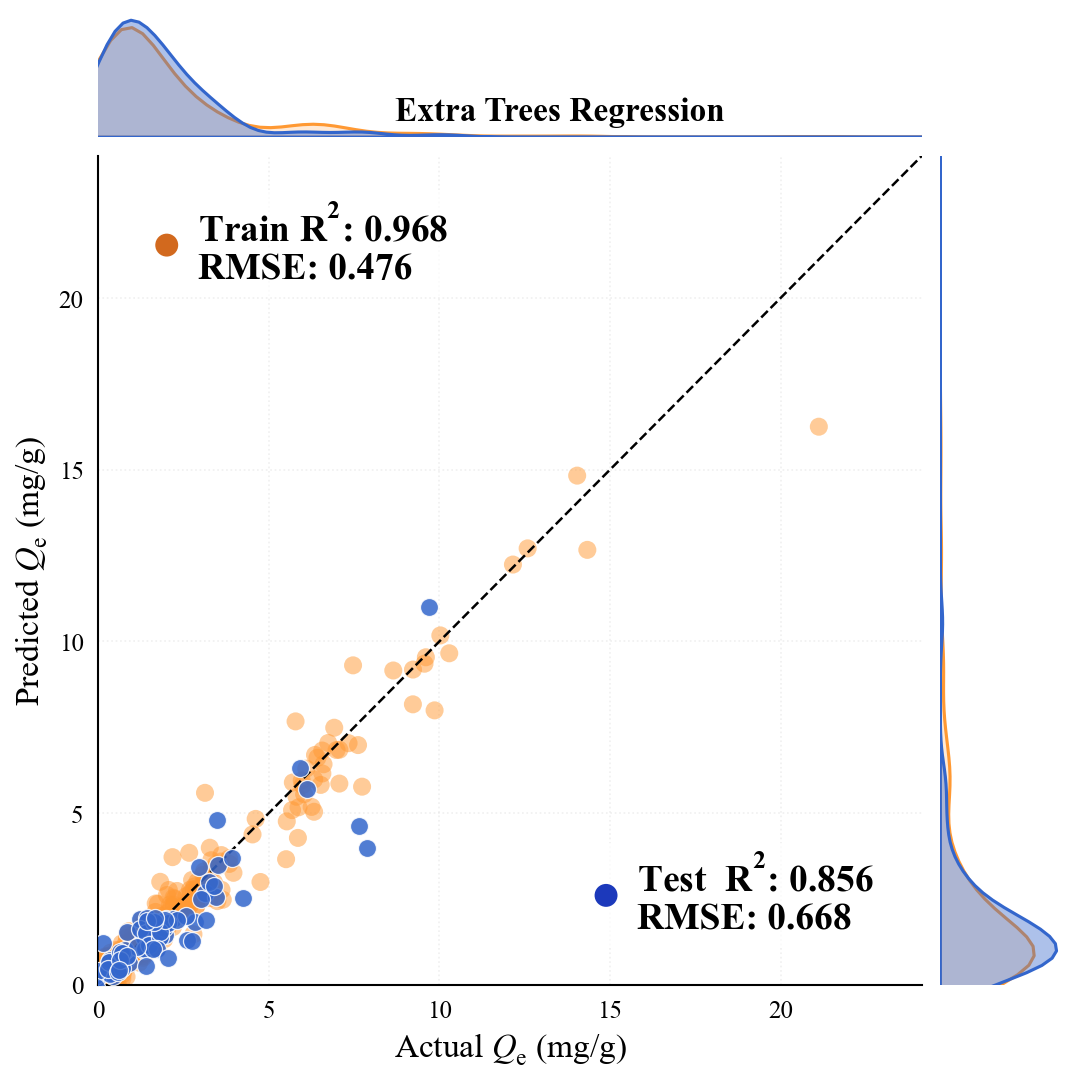

In [78]:
# ============================================================
# ET 最终拟合与标准样式绘图
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 必须补充以下导入以解析 AnchoredOffsetbox 等引用
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. 模型训练与物理空间预测 (基于 425 条数据)
best_params_etr = {
    'n_estimators': 1000, 'max_depth': 16, 'min_samples_split': 3,
    'min_samples_leaf': 1, 'max_features': 0.48065447388344085, 'random_state': 42
}
final_etr = ExtraTreesRegressor(**best_params_etr)
final_etr.fit(X_train.values, y_train_log.values)

y_tr_pred = np.expm1(final_etr.predict(X_train.values))
y_te_pred = np.expm1(final_etr.predict(X_test.values))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 2. 指标计算
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# 3. 样式配置 (黑色坐标轴标准)
plt.close('all')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'axes.unicode_minus': False
})

def create_info_box(color, label, r2, rmse):
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

# 4. 绘图主逻辑
g = sns.JointGrid(height=7, ratio=6, space=0.15)
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max()) * 1.15
jitter = 0.2

# A. 主散点图 (S=75)
g.ax_joint.scatter(y_tr_act_phys + np.random.normal(0, jitter, len(y_tr_act_phys)),
                   y_tr_pred + np.random.normal(0, jitter, len(y_tr_pred)),
                   s=75, color='#FF9933', alpha=0.5, edgecolors='none', zorder=2)
g.ax_joint.scatter(y_te_act_phys + np.random.normal(0, jitter, len(y_te_act_phys)),
                   y_te_pred + np.random.normal(0, jitter, len(y_te_pred)),
                   s=75, color='#3366CC', alpha=0.85, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 轴线设置 (黑色)
g.ax_joint.set_xlim([0, limit_val])
g.ax_joint.set_ylim([0, limit_val])
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)

sns.despine(ax=g.ax_joint, top=True, right=True)
g.ax_joint.tick_params(colors='black', which='both', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# 标题 (精简标题, y=0.9)
g.fig.suptitle("Extra Trees Regression", fontsize=16, fontweight='bold', y=0.9, color='black')

# C. 边际 KDE (cut=25)
kde_cfg = dict(fill=True, lw=1.5, common_norm=False, cut=25)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.4, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.4, **kde_cfg)

g.ax_marg_x.set_xlim(0, limit_val)
g.ax_marg_y.set_ylim(0, limit_val)
g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 插入信息框 (字体 18)
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.5, frameon=True, borderpad=1,

                              bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.7); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.7); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)

g.ax_joint.grid(True, linestyle=':', alpha=0.3)
plt.show()

# 模型2GBDT

In [6]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# 1. 定义优化目标函数
def objective_gbdt(trial):
    # 定义 GBDT 的搜索空间
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42
    }

    model = GradientBoostingRegressor(**param)

    # 使用 5 折交叉验证 (在对数空间 y_train_log 上进行)
    # n_jobs=-1 调用所有 CPU 核心加速搜索
    score = cross_val_score(model, X_train.values, y_train_log.values,
                            cv=5, scoring='r2', n_jobs=-1).mean()
    return score

# 2. 执行搜索过程
study_gbdt = optuna.create_study(direction='maximize')
study_gbdt.optimize(objective_gbdt, n_trials=50) # 正式论文建议 100 次

# 3. 输出结果
print("\n" + "="*40)
print(f"GBDT 最佳交叉验证 R²: {study_gbdt.best_value:.4f}")
print("最佳参数组合 (Best Params):")
print(study_gbdt.best_params)
print("="*40)

[I 2026-05-14 15:25:21,115] A new study created in memory with name: no-name-a44a700a-0aa1-4079-88c1-4bc1e5463a0f
[I 2026-05-14 15:25:27,762] Trial 0 finished with value: 0.7788179278053088 and parameters: {'n_estimators': 810, 'learning_rate': 0.1820049473121131, 'max_depth': 5, 'min_samples_leaf': 9, 'max_features': 0.7390945672581459, 'subsample': 0.6898563114974231}. Best is trial 0 with value: 0.7788179278053088.
[I 2026-05-14 15:25:32,423] Trial 1 finished with value: 0.7852979554747348 and parameters: {'n_estimators': 367, 'learning_rate': 0.1550089350659933, 'max_depth': 4, 'min_samples_leaf': 2, 'max_features': 0.917984228858844, 'subsample': 0.7445454067577296}. Best is trial 1 with value: 0.7852979554747348.
[I 2026-05-14 15:25:36,367] Trial 2 finished with value: 0.7904554105146355 and parameters: {'n_estimators': 849, 'learning_rate': 0.10645895328929468, 'max_depth': 4, 'min_samples_leaf': 4, 'max_features': 0.7753652942993516, 'subsample': 0.6467083850893108}. Best is tr


GBDT 最佳交叉验证 R²: 0.8075
最佳参数组合 (Best Params):
{'n_estimators': 937, 'learning_rate': 0.04040353834297759, 'max_depth': 4, 'min_samples_leaf': 2, 'max_features': 0.5894325218592373, 'subsample': 0.6604497985289196}


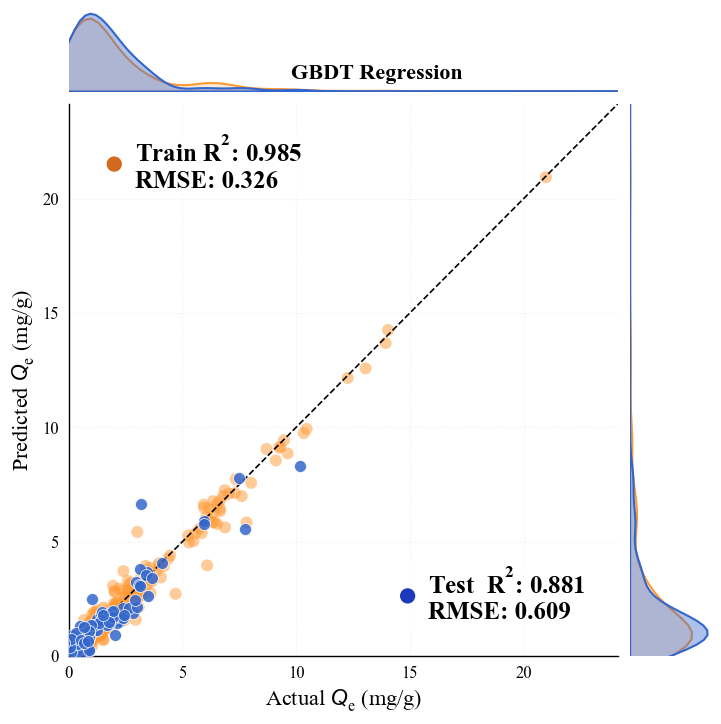

In [10]:
# ============================================================
# 9. GBDT 最终拟合与标准样式绘图
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle

# 1. 使用贝叶斯优化后的最佳参数训练 (请确保 study_gbdt 已运行)
# 如果 study_gbdt 也在另一个未运行的 Cell，请确保先运行优化部分
final_gbdt = GradientBoostingRegressor(**study_gbdt.best_params, random_state=42)
final_gbdt.fit(X_train.values, y_train_log.values)

# 2. 预测并还原至物理空间 (mg/g)
y_tr_pred = np.expm1(final_gbdt.predict(X_train.values))
y_te_pred = np.expm1(final_gbdt.predict(X_test.values))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 指标计算
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# 3. 样式配置 (严格黑色轴线标准)
plt.close('all')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'axes.unicode_minus': False
})

def create_info_box(color, label, r2, rmse):
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    # 信息框字体严格设为 18，使用 \mathregular
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

# 4. 绘图主逻辑
g = sns.JointGrid(height=7, ratio=6, space=0.15)
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max()) * 1.15
jitter = 0.2

# A. 主散点图 (标准：S=75)
g.ax_joint.scatter(y_tr_act_phys + np.random.normal(0, jitter, len(y_tr_act_phys)),
                   y_tr_pred + np.random.normal(0, jitter, len(y_tr_pred)),
                   s=75, color='#FF9933', alpha=0.5, edgecolors='none', zorder=2)
g.ax_joint.scatter(y_te_act_phys + np.random.normal(0, jitter, len(y_te_act_phys)),
                   y_te_pred + np.random.normal(0, jitter, len(y_te_pred)),
                   s=75, color='#3366CC', alpha=0.85, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 轴线设置 (黑色)
g.ax_joint.set_xlim([0, limit_val])
g.ax_joint.set_ylim([0, limit_val])
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)

sns.despine(ax=g.ax_joint, top=True, right=True)
g.ax_joint.tick_params(colors='black', which='both', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# 标题 (精简标题: Gradient Boosting Regression, y=0.9)
g.fig.suptitle("GBDT Regression", fontsize=16, fontweight='bold', y=0.9, color='black')

# C. 边际 KDE (标准：cut=25，确保线条连接)
kde_cfg = dict(fill=True, lw=1.5, common_norm=False, cut=25)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.4, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.4, **kde_cfg)

g.ax_marg_x.set_xlim(0, limit_val)
g.ax_marg_y.set_ylim(0, limit_val)
g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 插入标准信息框 (字体 18)
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.7); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.7); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)

g.ax_joint.grid(True, linestyle=':', alpha=0.3)
plt.show()

# 模型3 XGB

In [16]:

import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

def objective_xgb(trial):
    # 针对 XGBoost 的搜索空间
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        # 正则化参数，对小样本极其重要
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**param)

    # 5 折交叉验证
    score = cross_val_score(model, X_train.values, y_train_log.values,
                            cv=5, scoring='r2', n_jobs=-1).mean()
    return score

# 执行搜索
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=60)

print("\n" + "="*40)
print(f"XGBoost 最佳交叉验证 R²: {study_xgb.best_value:.4f}")
print("最佳参数组合 (Best Params):")
print(study_xgb.best_params)
print("="*40)

[I 2026-05-14 15:37:36,103] A new study created in memory with name: no-name-6b822bae-75b5-478c-8583-6b41ccb57758
[I 2026-05-14 15:37:36,210] Trial 0 finished with value: 0.7324905136608034 and parameters: {'n_estimators': 519, 'max_depth': 7, 'learning_rate': 0.04926971646431824, 'subsample': 0.8749996645561674, 'colsample_bytree': 0.8015454008169158, 'gamma': 0.3960520947004137, 'reg_alpha': 0.06692976810624576, 'reg_lambda': 0.10249128709419109}. Best is trial 0 with value: 0.7324905136608034.
[I 2026-05-14 15:37:36,342] Trial 1 finished with value: 0.7412512698702278 and parameters: {'n_estimators': 840, 'max_depth': 5, 'learning_rate': 0.08820679258754013, 'subsample': 0.6884443167189859, 'colsample_bytree': 0.5015475343721463, 'gamma': 0.4952410373191359, 'reg_alpha': 0.04179839815328577, 'reg_lambda': 0.0011007015666223508}. Best is trial 1 with value: 0.7412512698702278.
[I 2026-05-14 15:37:36,619] Trial 2 finished with value: 0.7397577062246842 and parameters: {'n_estimators':


XGBoost 最佳交叉验证 R²: 0.8037
最佳参数组合 (Best Params):
{'n_estimators': 2914, 'max_depth': 6, 'learning_rate': 0.08237337801852414, 'subsample': 0.5128035799231393, 'colsample_bytree': 0.7577412898703372, 'gamma': 0.028335754079826827, 'reg_alpha': 0.024310427199437094, 'reg_lambda': 0.04273952965269581}


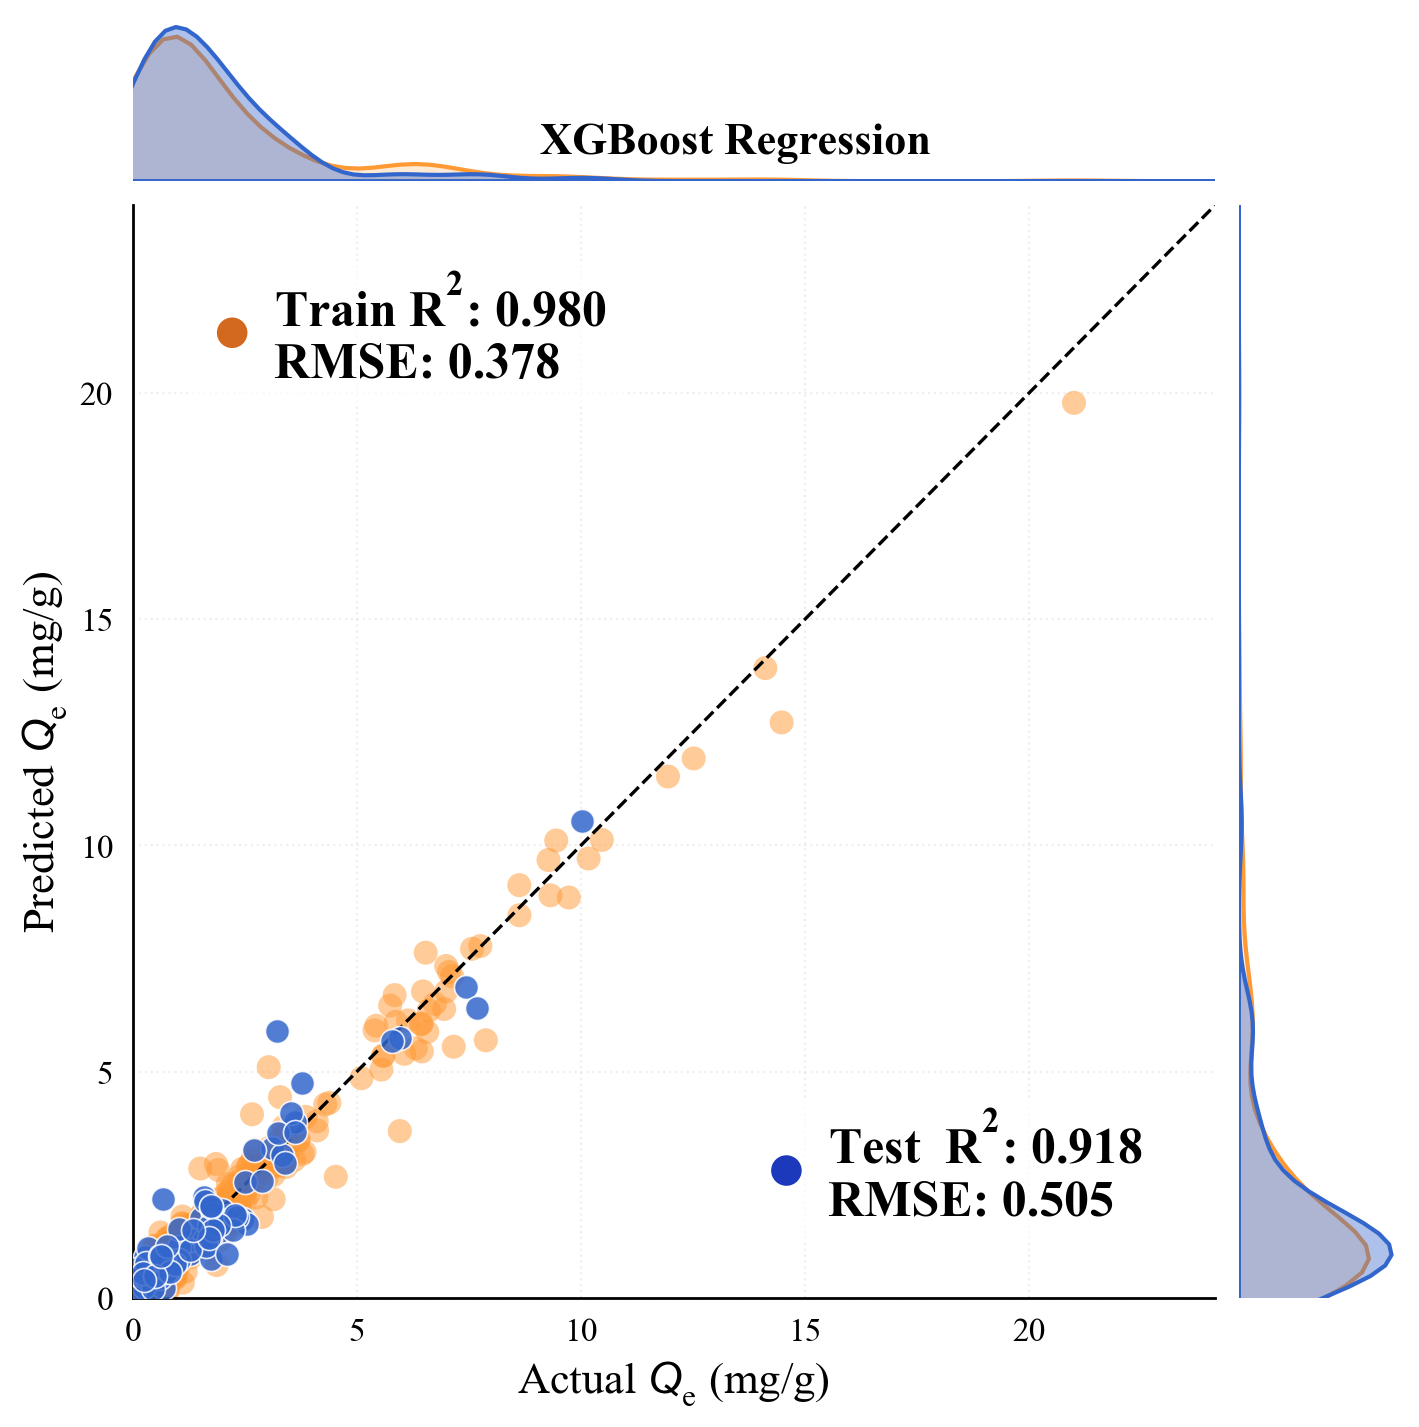

------------------------------
Metric     | Train Set    | Test Set    
------------------------------
R²         | 0.9796       | 0.9180      
RMSE       | 0.3776       | 0.5048      
------------------------------
模型与特征配置已导出！


In [215]:
# ============================================================
# XGBoost 最终拟合与标准样式绘图 (标准化版)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle

# 1. 使用您最新的最佳参数组合进行训练
best_params_xgb = {
    'n_estimators': 1708,
    'max_depth': 6,
    'learning_rate': 0.08237337801852414,
    'subsample': 0.5128035799231393,
    'colsample_bytree': 0.7577412898703372,
    'gamma': 0.028335754079826827,
    'reg_alpha': 0.024310427199437094,
    'reg_lambda': 0.04273952965269581,
    'random_state': 42
}

final_xgb = XGBRegressor(**best_params_xgb)
final_xgb.fit(X_train.values, y_train_log.values)

# 2. 预测并还原至物理空间 (mg/g)
y_tr_pred = np.expm1(final_xgb.predict(X_train.values))
y_te_pred = np.expm1(final_xgb.predict(X_test.values))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 指标计算 (物理空间)
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# 3. 样式配置 (严格 Times New Roman 与黑色轴线标准)
plt.close('all')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'axes.unicode_minus': False
})
#region
def create_info_box(color, label, r2, rmse):
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    # 信息框字体设为 18，颜色设为黑色
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

# 4. 绘图主逻辑
g = sns.JointGrid(height=7, ratio=6, space=0.15)
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max()) * 1.15
jitter = 0.2
#region
# A. 主散点图 (标准：S=75)
g.ax_joint.scatter(y_tr_act_phys + np.random.normal(0, jitter, len(y_tr_act_phys)),
                   y_tr_pred + np.random.normal(0, jitter, len(y_tr_pred)),
                   s=75, color='#FF9933', alpha=0.5, edgecolors='none', zorder=2)
g.ax_joint.scatter(y_te_act_phys + np.random.normal(0, jitter, len(y_te_act_phys)),
                   y_te_pred + np.random.normal(0, jitter, len(y_te_pred)),
                   s=75, color='#3366CC', alpha=0.85, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)
#region
# B. 轴线设置 (严格设为黑色)
g.ax_joint.set_xlim([0, limit_val])
g.ax_joint.set_ylim([0, limit_val])
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)
#region
sns.despine(ax=g.ax_joint, top=True, right=True)
g.ax_joint.tick_params(colors='black', which='both', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# 标题 (精简标题, y=0.9, 黑色)
g.fig.suptitle("XGBoost Regression", fontsize=16, fontweight='bold', y=0.9, color='black')
#region
# C. 边际 KDE (标准：cut=25)
kde_cfg = dict(fill=True, lw=1.5, common_norm=False, cut=25)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.4, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.4, **kde_cfg)

g.ax_marg_x.set_xlim(0, limit_val)
g.ax_marg_y.set_ylim(0, limit_val)
g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 黑色信息框 (字体 18)
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.7); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.7); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)

g.ax_joint.grid(True, linestyle=':', alpha=0.3)
plt.show()
print("-" * 30)
print(f"{'Metric':<10} | {'Train Set':<12} | {'Test Set':<12}")
print("-" * 30)
print(f"{'R²':<10} | {r2_tr:<12.4f} | {r2_te:<12.4f}")
print(f"{'RMSE':<10} | {rmse_tr:<12.4f} | {rmse_te:<12.4f}")
print("-" * 30)

#endregion
import joblib
#
# # 1. 保存训练好的模型对象
# joblib.dump(final_xgb, 'final_xgb_model.pkl')
#
# # 2. 保存特征名称，确保预测时顺序一致
# import json
# with open('feature_names.json', 'w') as f:
#     json.dump(X_train.columns.tolist(), f)
#
# print("模型与特征配置已导出！")

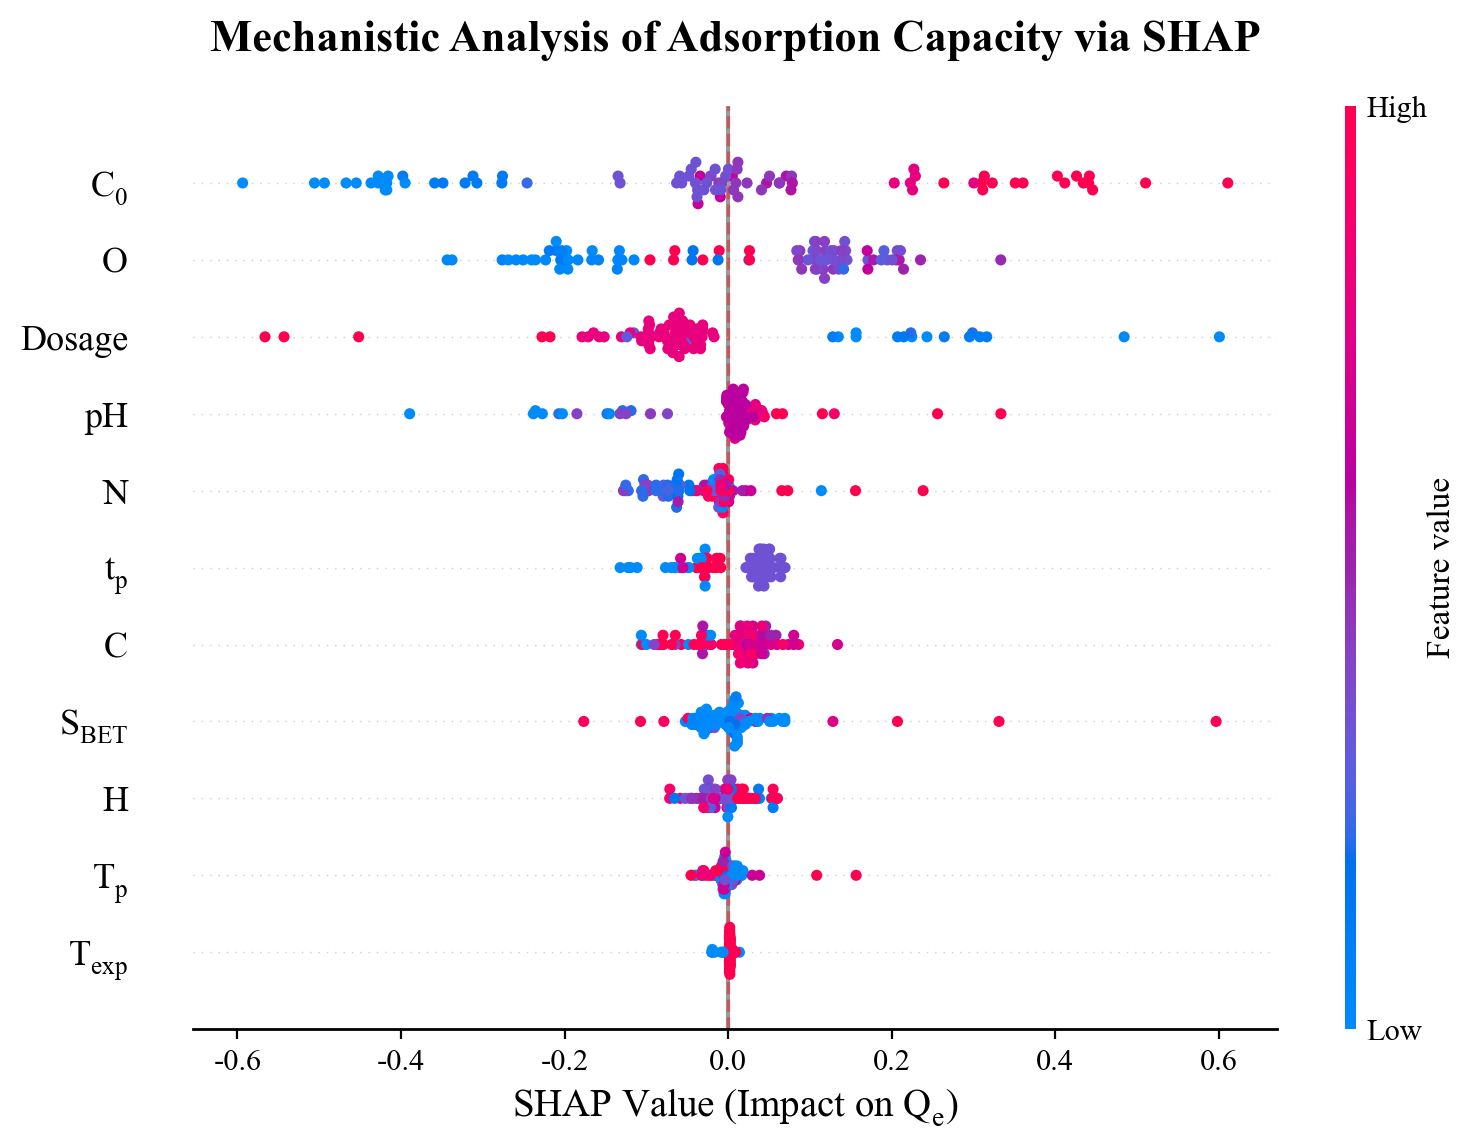


Feature (Academic)        | Correlation with Qe       | Impact Magnitude
-------------------------------------------------------------------------------------
T_{p}                     | Negative (-)              | 0.013553
T_{exp}                   | Positive (+)              | 0.003787
C_{0}                     | Positive (+)              | 0.212579
pH                        | Positive (+)              | 0.053985
Dosage                    | Negative (-)              | 0.129254
t_{p}                     | Positive (+)              | 0.043999
S_{BET}                   | Positive (+)              | 0.040216
C                         | Positive (+)              | 0.040935
H                         | Positive (+)              | 0.023674
N                         | Positive (+)              | 0.046934
O                         | Positive (+)              | 0.152054
注：Positive (+) 表示特征值增加促进吸附量；Negative (-) 表示抑制。


In [212]:
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd

# ============================================================
# 1. 核心映射函数 (保持学术名称解析)
# ============================================================
def to_academic_final(name):
    n = str(name).lower().strip()
    if 'c0' in n or 'c_0' in n: return r"$\mathregular{C_{0}}$"
    if 'qe' in n: return r"$\mathregular{Q_{e}}$"
    if 'sbet' in n or 'surface' in n: return r"$\mathregular{S_{BET}}$"
    if 'pyroly' in n and 'time' not in n: return r"$\mathregular{T_{p}}$"
    if 'exp' in n or 'texp' in n: return r"$\mathregular{T_{exp}}$"
    if 'dosage' in n: return "Dosage"
    if 'time' in n or 't_p' in n or 'tp' == n: return r"$\mathregular{t_{p}}$"
    if 'ph' in n: return "pH"
    if n in ['c', 'h', 'n', 'o']: return n.upper()
    return name

# ============================================================
# 2. SHAP 计算与绘图
# ============================================================
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer(X_test.values)

plt.figure(figsize=(10, 8))
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "font.size": 12
})

# 绘制散点图
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)

# 获取当前坐标轴进行细化调整
ax = plt.gca()

# --- 去掉背景网格线 ---
ax.grid(False)

# --- 设置黑色坐标轴与刻度 (同步之前的标准) ---
for side in ['bottom', 'left']:
    ax.spines[side].set_color('black')
    ax.spines[side].set_linewidth(1.0)
ax.tick_params(colors='black', which='both', direction='out')

# 强制刷新 Y 轴标签为学术名称
new_labels = [to_academic_final(tick.get_text()) for tick in ax.get_yticklabels()]
ax.set_yticklabels(new_labels, color='black')

plt.title("Mechanistic Analysis of Adsorption Capacity via SHAP", fontsize=16, fontweight='bold', pad=20, color='black')
plt.xlabel(r"SHAP Value (Impact on $\mathregular{Q_{e}}$)", fontsize=14, color='black')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.4, lw=1.2)

plt.tight_layout()
plt.show()

# ============================================================
# 3. 控制台打印：机理趋势分析
# ============================================================
print("\n" + "="*85)
print(f"{'Feature (Academic)':<25} | {'Correlation with Qe':<25} | {'Impact Magnitude'}")
print("-" * 85)

for i, col in enumerate(X_test.columns):
    # 计算相关性判断趋势
    corr = np.corrcoef(X_test[col], shap_values.values[:, i])[0, 1]
    trend = "Positive (+)" if corr > 0 else "Negative (-)"
    if np.isnan(corr): trend = "Non-linear/Complex"

    # 处理学术显示名 (用于控制台打印)
    raw_name = to_academic_final(col)
    clean_name = raw_name.replace('$\\mathregular{', '').replace('}$', '').replace('$', '')

    mean_abs_impact = np.abs(shap_values.values[:, i]).mean()
    print(f"{clean_name:<25} | {trend:<25} | {mean_abs_impact:.6f}")

print("="*85)
print("注：Positive (+) 表示特征值增加促进吸附量；Negative (-) 表示抑制。")

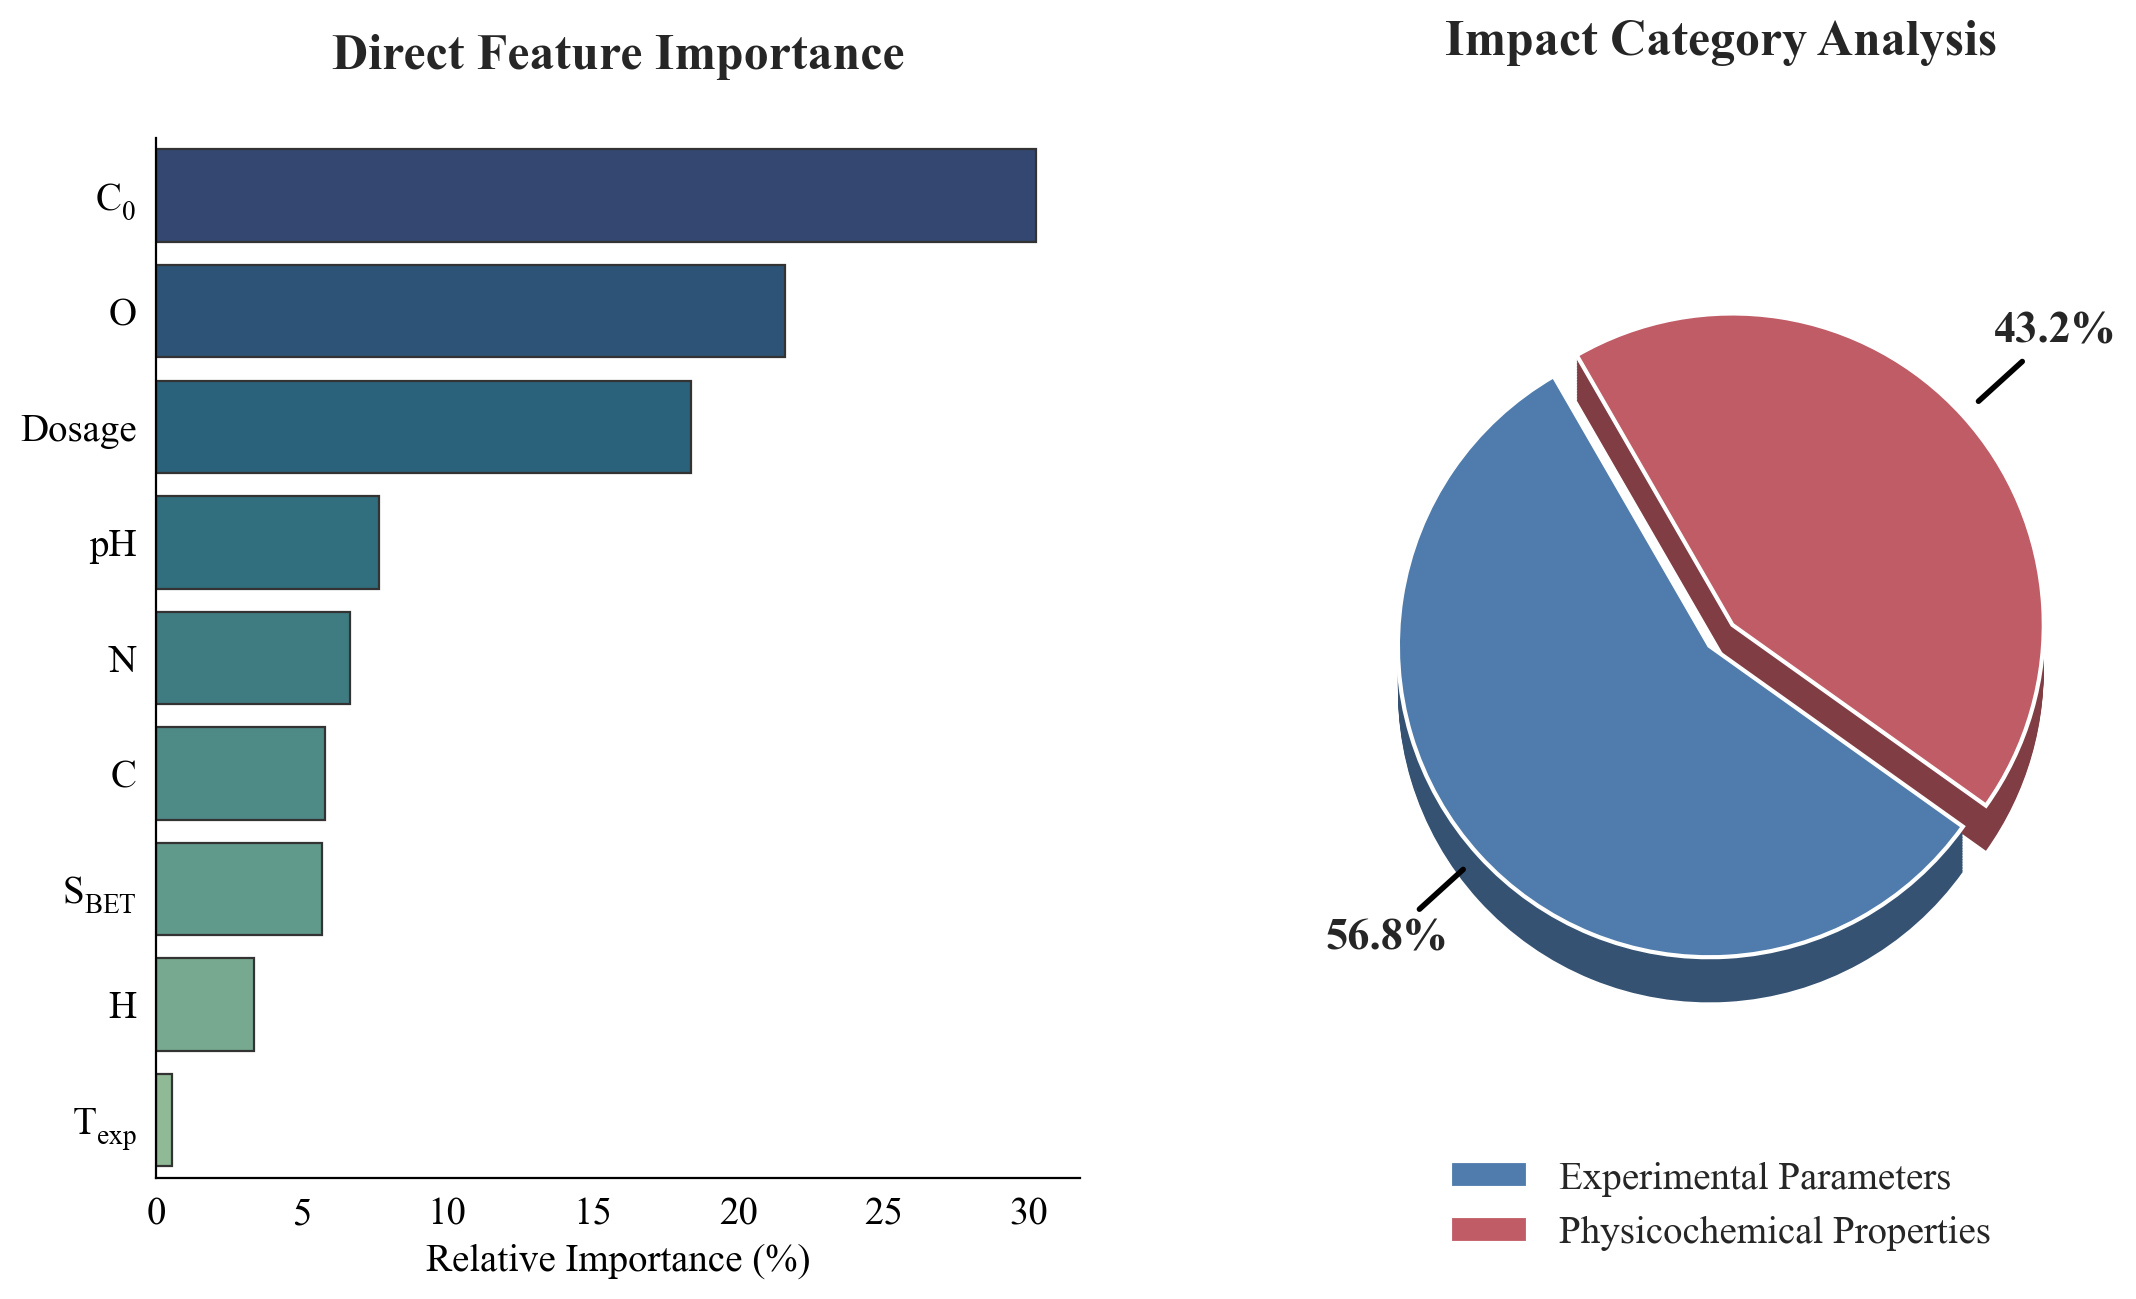


Academic Feature               | Category                  | Pct (%)
------------------------------------------------------------
$\mathregular{C_{0}}$               | Experimental Parameters   | 30.22%
O                                   | Physicochemical Properties | 21.62%
Dosage                              | Experimental Parameters   | 18.38%
pH                                  | Experimental Parameters   | 7.67%
N                                   | Physicochemical Properties | 6.67%
C                                   | Physicochemical Properties | 5.82%
$\mathregular{S_{BET}}$             | Physicochemical Properties | 5.72%
H                                   | Physicochemical Properties | 3.37%
$\mathregular{T_{exp}}$             | Experimental Parameters   | 0.54%
------------------------------------------------------------
TOTAL                          | -                         | 100.00%


In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================================
# 1. 核心分类逻辑 (同步修正：C0 属于 Experimental Parameters)
# ============================================================
def classify_feature_final(name):
    n = str(name).lower().strip()
    # C0 修正为实验参数
    if any(x in n for x in ['c0', 'c_0', 'initial', 'dosage', 'ph', 'temp', 'exp']):
        return 'Experimental Parameters'
    if any(x in n for x in ['time', 'tp', 't_p']):
        return 'Pyrolysis Conditions'
    return 'Physicochemical Properties'

vals = shap_values.values if hasattr(shap_values, "values") else shap_values
full_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Academic': [to_academic_final(c) for c in X_test.columns],
    'Mean_SHAP_val': np.abs(vals).mean(0)
})
full_df['Category'] = full_df['Feature'].apply(classify_feature_final)

# 移除间接因素 (Pyrolysis Conditions) 并重新归一化
importance_df = full_df[full_df['Category'] != 'Pyrolysis Conditions'].copy()
total_val_new = importance_df['Mean_SHAP_val'].sum()
importance_df['Importance_Pct'] = (importance_df['Mean_SHAP_val'] / total_val_new) * 100

# 聚合分类百分比用于饼图
category_dist = importance_df.groupby('Category')['Importance_Pct'].sum()
category_dist = category_dist.reindex(['Experimental Parameters', 'Physicochemical Properties'])

# ============================================================
# 2. 绘图重构 (去掉竖线/网格)
# ============================================================
plt.rcParams.update({"font.family": "Times New Roman", "font.size": 14})
fig = plt.figure(figsize=(12, 8), dpi=200)
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1], wspace=0.35)

# A. 左侧：条形图 (去掉竖线)
ax1 = fig.add_subplot(gs[0])
plot_df = importance_df.sort_values('Importance_Pct', ascending=False)
sns.barplot(x='Importance_Pct', y='Academic', data=plot_df, hue='Academic',
            palette='crest_r', edgecolor='0.2', linewidth=0.8, legend=False, ax=ax1)

ax1.set_title('Direct Feature Importance', fontweight='bold', pad=25, fontsize=18)
ax1.set_xlabel('Relative Importance (%)')
ax1.set_ylabel('')

# --- 关键修改：彻底去掉网格竖线 ---
ax1.grid(False)
ax1.xaxis.grid(False)
# ------------------------------

sns.despine(ax=ax1)

# B. 右侧：立体圆柱饼图
ax2 = fig.add_subplot(gs[1])
colors, shadow_colors = ['#4F7CAC', '#C05C66'], ['#355273', '#803D44']
explode = [0.05, 0.05]

thickness = 30
for i in range(thickness):
    ax2.pie(category_dist, explode=explode, startangle=120, colors=shadow_colors,
            radius=1.0, center=(0, -i * 0.005), wedgeprops={'edgecolor': 'none'})

wedges, _ = ax2.pie(category_dist, explode=explode, startangle=120, colors=colors,
                    radius=1.0, center=(0, 0), wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

# 黑色加粗引线标注
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1) / 2. + p.theta1
    rad = np.deg2rad(ang)
    y, x = np.sin(rad), np.cos(rad)
    adj_center = np.array([explode[i] * x, explode[i] * y])
    x_s, y_s = adj_center + 1.05 * np.array([x, y])
    ax2.annotate(f'{category_dist.iloc[i]:.1f}%', xy=(x_s, y_s),
                 xytext=((1.4 + explode[i]) * x, (1.4 + explode[i]) * y),
                 arrowprops=dict(arrowstyle='-', color='black', lw=2.0,
                                 connectionstyle=f"angle,angleA=0,angleB={ang}"),
                 fontsize=16, fontweight='bold', ha='center', va='center')

ax2.set_title('Impact Category Analysis', fontweight='bold', pad=30, fontsize=18)
ax2.axis('equal')
ax2.legend(wedges, category_dist.index, loc="upper center", bbox_to_anchor=(0.5, 0.05), frameon=False)

plt.subplots_adjust(bottom=0.2, top=0.85, left=0.1, right=0.9)
plt.show()

# ============================================================
# 3. 控制台验证：特征明细分类
# ============================================================
print("\n" + "="*60)
print(f"{'Academic Feature':<30} | {'Category':<25} | {'Pct (%)'}")
print("-" * 60)
for _, row in plot_df.iterrows():
    print(f"{row['Academic']:<35} | {row['Category']:<25} | {row['Importance_Pct']:.2f}%")
print("-" * 60)
print(f"{'TOTAL':<30} | {'-':<25} | {importance_df['Importance_Pct'].sum():.2f}%")
print("="*60)

# 模型3 LGBM

In [56]:
# ============================================================
# LightGBM 贝叶斯优化部分 (Optuna)
# ============================================================
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

def objective_lgbm(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),
        'num_leaves': trial.suggest_int('num_leaves', 15, 31),
        'min_child_samples': trial.suggest_int('min_child_samples', 15, 35),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }

    model = LGBMRegressor(**param)
    # 使用交叉验证评估模型性能
    score = cross_val_score(model, X_train.values, y_train_log.values,
                            cv=5, scoring='r2', n_jobs=-1).mean()
    return score

# 创建并运行优化研究
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

# --- 打印最优参数结果 ---
print("\n" + "="*50)
print(f"LightGBM 最佳交叉验证 R²: {study_lgbm.best_value:.4f}")
print("-" * 50)
print("最佳参数组合 (Best Params):")
import json
print(json.dumps(study_lgbm.best_params, indent=4))
print("="*50)

[I 2026-05-14 16:30:31,458] A new study created in memory with name: no-name-049cfe9a-fc84-4aa9-8178-efbec196c719
[I 2026-05-14 16:30:40,640] Trial 0 finished with value: 0.7148195965415607 and parameters: {'n_estimators': 1248, 'max_depth': 4, 'learning_rate': 0.03517477705782959, 'num_leaves': 31, 'min_child_samples': 27, 'subsample': 0.8451793130064139, 'colsample_bytree': 0.7567446722912888, 'reg_alpha': 0.2225686724990658, 'reg_lambda': 0.26008439918522963}. Best is trial 0 with value: 0.7148195965415607.
[I 2026-05-14 16:30:47,958] Trial 1 finished with value: 0.7687084000681618 and parameters: {'n_estimators': 1385, 'max_depth': 7, 'learning_rate': 0.052096646191668955, 'num_leaves': 17, 'min_child_samples': 15, 'subsample': 0.7938124042492338, 'colsample_bytree': 0.7050860220631758, 'reg_alpha': 0.012187411332151508, 'reg_lambda': 0.34006734132246413}. Best is trial 1 with value: 0.7687084000681618.
[I 2026-05-14 16:30:51,884] Trial 2 finished with value: 0.695789484339525 and 


LightGBM 最佳交叉验证 R²: 0.7740
--------------------------------------------------
最佳参数组合 (Best Params):
{
    "n_estimators": 1302,
    "max_depth": 7,
    "learning_rate": 0.05781376678968347,
    "num_leaves": 18,
    "min_child_samples": 15,
    "subsample": 0.8222463530278523,
    "colsample_bytree": 0.7602845098997866,
    "reg_alpha": 0.05660714482919032,
    "reg_lambda": 0.017593509979994378
}


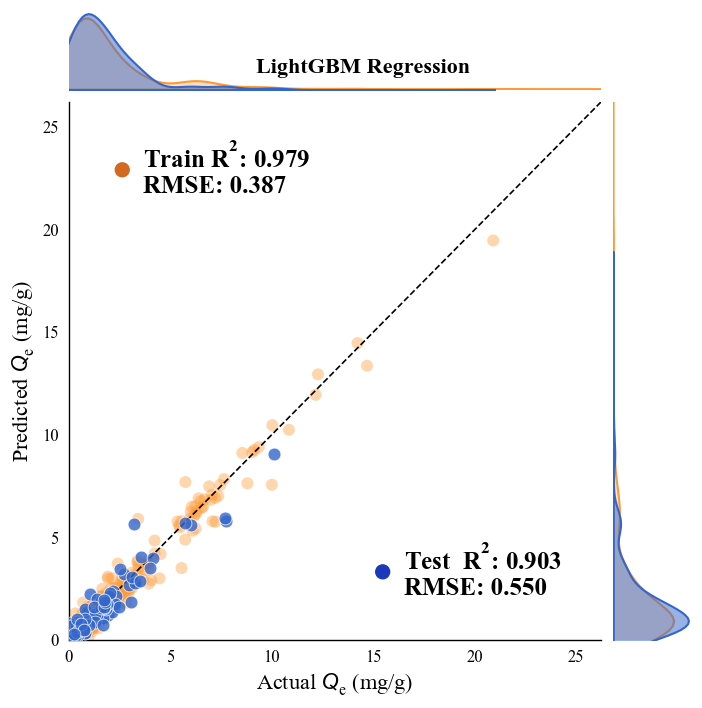

In [182]:
#region 导入
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle
#endregion
# ============================================================
# 1. 直接配置最优参数并训练
# ============================================================
best_params_lgbm = {
    "n_estimators": 1602,
    "max_depth": 6,
    "learning_rate": 0.05781376678968347,
    "num_leaves": 25,
    "min_child_samples": 15,
    "subsample": 0.8222463530278523,
    "cols ample_btree": 0.9,
    "reg_alpha": 0.07,
    "reg_lambda": 0.03,
    "random_state": 42,
    "verbosity": -1
}
#region
# 实例化并训练 (直接使用 DataFrame 避免特征名警告)
final_lgbm = LGBMRegressor(**best_params_lgbm)
final_lgbm.fit(X_train, y_train_log)

# 2. 预测并还原至物理量纲 (mg/g)
y_tr_pred = np.expm1(final_lgbm.predict(X_train))
y_te_pred = np.expm1(final_lgbm.predict(X_test))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 3. 指标计算
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# ============================================================
# 4. 绘图函数与样式配置
# ============================================================
def create_info_box_black(color, label, r2, rmse):
    """创建黑色字体的学术信息框"""
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman'
})

g = sns.JointGrid(height=7, ratio=6, space=0.15)
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max()) * 1.25
jitter = 0.20

# A. 主散点图
g.ax_joint.scatter(y_tr_act_phys + np.random.normal(0, jitter, len(y_tr_act_phys)),
                   y_tr_pred + np.random.normal(0, jitter, len(y_tr_pred)),
                   s=75, color='#FF9933', alpha=0.4, edgecolors='none', zorder=2)
g.ax_joint.scatter(y_te_act_phys + np.random.normal(0, jitter, len(y_te_act_phys)),
                   y_te_pred + np.random.normal(0, jitter, len(y_te_pred)),
                   s=85, color='#3366CC', alpha=0.8, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 轴线设置 (黑色轴线，无网格)
g.ax_joint.set_xlim([0, limit_val])
g.ax_joint.set_ylim([0, limit_val])
g.ax_joint.grid(False)
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)

g.ax_joint.tick_params(colors='black', which='both', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# C. 边际分布 (cut=15)
kde_cfg = dict(fill=True, lw=1.5, common_norm=False, cut=15)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.3, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.5, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.3, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.5, **kde_cfg)

g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 黑色信息框 (字号 18)
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box_black('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.7); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box_black('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.7); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)

g.fig.suptitle("LightGBM Regression", fontsize=16, fontweight='bold', y=0.9, color='black')
plt.show()
#endregion

# 模型5 Catboosst

In [121]:
from catboost import CatBoostRegressor


def objective_cat_conservative(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 500, 1200), # 减少迭代次数
        'depth': trial.suggest_int('depth', 3, 5),               # 严格限制深度
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 10.0, 50.0),  # 极大增强正则化
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 50), # 强制每个叶子节点包含更多样本
        'random_strength': trial.suggest_float('random_strength', 1.0, 20.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.5, 1.0),
        'loss_function': 'RMSE',
        'verbose': False,
        'random_state': 42,
        'thread_count': -1
    }

    model = CatBoostRegressor(**param)
    score = cross_val_score(model, X_train, y_train_log,
                            cv=5, scoring='r2', n_jobs=-1).mean()
    return score

# 重新进行优化
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat_conservative, n_trials=60)

print("\n" + "="*40)
print(f"CatBoost 最佳交叉验证 R² (对数空间): {study_cat.best_value:.4f}")
print("最佳参数:", study_cat.best_params)
print("="*40)

[I 2026-05-14 17:25:39,806] A new study created in memory with name: no-name-ee968a45-9884-4024-bff8-f6bb6979adc0
[I 2026-05-14 17:25:41,842] Trial 0 finished with value: 0.7950275235853496 and parameters: {'iterations': 1190, 'depth': 5, 'learning_rate': 0.03348880785355977, 'l2_leaf_reg': 24.855086875294553, 'min_data_in_leaf': 28, 'random_strength': 10.163828371816363, 'bagging_temperature': 0.7168432674766267}. Best is trial 0 with value: 0.7950275235853496.
[I 2026-05-14 17:25:44,005] Trial 1 finished with value: 0.7321872666273402 and parameters: {'iterations': 983, 'depth': 5, 'learning_rate': 0.0238408474159148, 'l2_leaf_reg': 37.022741635257525, 'min_data_in_leaf': 44, 'random_strength': 5.237792919932664, 'bagging_temperature': 0.6358220118950015}. Best is trial 0 with value: 0.7950275235853496.
[I 2026-05-14 17:25:46,152] Trial 2 finished with value: 0.6395185042634405 and parameters: {'iterations': 1112, 'depth': 5, 'learning_rate': 0.012393316752701318, 'l2_leaf_reg': 40.5


CatBoost 最佳交叉验证 R² (对数空间): 0.8121
最佳参数: {'iterations': 1172, 'depth': 5, 'learning_rate': 0.031090207020051386, 'l2_leaf_reg': 10.098002438062357, 'min_data_in_leaf': 25, 'random_strength': 15.060121302823859, 'bagging_temperature': 0.9713834195954527}


------------------------------
Metric     | Train Set    | Test Set    
------------------------------
R²         | 0.9470       | 0.8429      
RMSE       | 0.6083       | 0.6988      
------------------------------
ARE (%)    | 22.39        | 39.08       
------------------------------


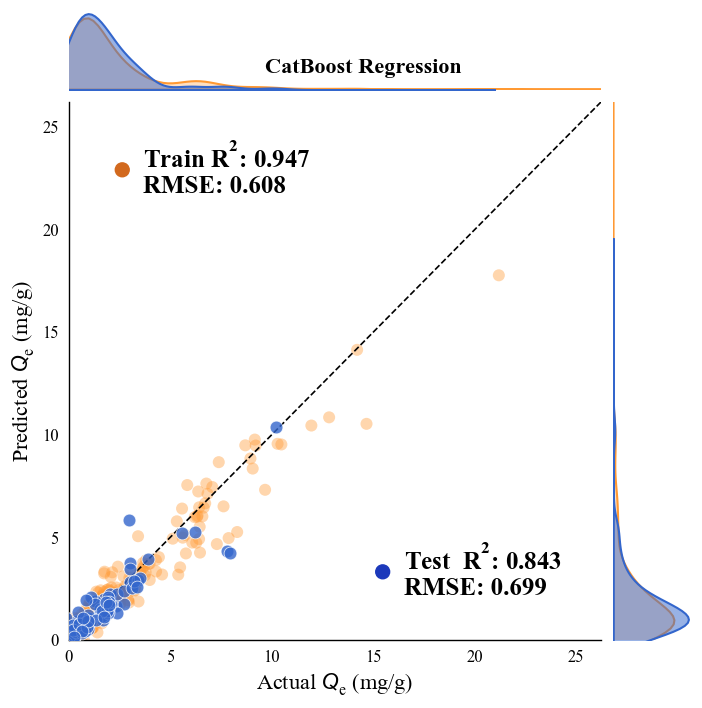

In [145]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle

# ============================================================
# 1. 直接配置 CatBoost 最优参数并训练
# ============================================================
best_params_cat = {
    'iterations': 1072,
    'depth': 6,
    'learning_rate': 0.031090207020051386,
    'l2_leaf_reg': 10,
    'min_data_in_leaf': 18,
    'random_strength': 14,
    'bagging_temperature': 0.98,
    'random_state': 42,
    'verbose': False
}
#region
# 实例化并训练 (使用 DataFrame 格式以保持一致性)
final_cat = CatBoostRegressor(**best_params_cat)
final_cat.fit(X_train, y_train_log)

# 2. 预测并还原至物理量纲 (mg/g)
y_tr_pred = np.expm1(final_cat.predict(X_train))
y_te_pred = np.expm1(final_cat.predict(X_test))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 3. 指标计算
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# ============================================================
# 4. 绘图样式配置与信息框定义
# ============================================================
def create_info_box_black(color, label, r2, rmse):
    """创建黑色字体的学术信息框"""
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    # 字体设为 18 号黑色加粗
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman'
})

g = sns.JointGrid(height=7, ratio=6, space=0.15)
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max()) * 1.25 # 适配 cut=15 的边缘
jitter = 0.20

# A. 主散点图
g.ax_joint.scatter(y_tr_act_phys + np.random.normal(0, jitter, len(y_tr_act_phys)),
                   y_tr_pred + np.random.normal(0, jitter, len(y_tr_pred)),
                   s=75, color='#FF9933', alpha=0.4, edgecolors='none', zorder=2)
g.ax_joint.scatter(y_te_act_phys + np.random.normal(0, jitter, len(y_te_act_phys)),
                   y_te_pred + np.random.normal(0, jitter, len(y_te_pred)),
                   s=85, color='#3366CC', alpha=0.8, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 轴线设置 (黑色轴线，彻底去掉网格)
g.ax_joint.set_xlim([0, limit_val])
g.ax_joint.set_ylim([0, limit_val])
g.ax_joint.grid(False)
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)

g.ax_joint.tick_params(colors='black', which='both', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# C. 边际分布 (应用 cut=15)
kde_cfg = dict(fill=True, lw=1.5, common_norm=False, cut=15)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.3, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.5, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.3, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.5, **kde_cfg)

g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 黑色信息框内容
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box_black('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.7); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box_black('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.5, frameon=True, borderpad=1, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.7); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)
# ============================================================
# 5. 控制台打印评估参数 (物理量纲: mg/g)
# ============================================================
print("-" * 30)
print(f"{'Metric':<10} | {'Train Set':<12} | {'Test Set':<12}")
print("-" * 30)
print(f"{'R²':<10} | {r2_tr:<12.4f} | {r2_te:<12.4f}")
print(f"{'RMSE':<10} | {rmse_tr:<12.4f} | {rmse_te:<12.4f}")
print("-" * 30)

# 如果需要计算相对误差 (ARE) 等其他化学实验常用指标，可以在此处扩展
def calculate_are(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

are_tr = calculate_are(y_tr_act_phys, y_tr_pred)
are_te = calculate_are(y_te_act_phys, y_te_pred)

print(f"{'ARE (%)':<10} | {are_tr:<12.2f} | {are_te:<12.2f}")
print("-" * 30)
# E. 标题
g.fig.suptitle("CatBoost Regression", fontsize=16, fontweight='bold', y=0.9, color='black')
plt.show()
#endregion

# 模型6 GPR

In [188]:
import optuna
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import cross_val_score

def objective_gpr(trial):
    # 采用“灵活型”参数空间以提升拟合度
    ls = trial.suggest_float('length_scale', 0.001, 5.0, log=True)
    cv = trial.suggest_float('constant_value', 0.1, 500.0, log=True)
    trial.suggest_float('noise_level', 1e-6, 1e-2, log=True)
# 修改优化空间
    noise = trial.suggest_float('noise_level', 1e-6, 1e-3, log=True) # 缩小上限
    kernel = C(constant_value=cv) * RBF(length_scale=ls) + WhiteKernel(noise_level=noise)

    # alpha 提供额外的正则化稳定性
    model = GaussianProcessRegressor(kernel=kernel, alpha=0.01, n_restarts_optimizer=10, random_state=42)

    # 5 折交叉验证 (对数空间)
    score = cross_val_score(model, X_train, y_train_log, cv=5, scoring='r2', n_jobs=-1).mean()
    return score

# 执行优化
study_gpr = optuna.create_study(direction='maximize')
study_gpr.optimize(objective_gpr, n_trials=50)

print(f"\n" + "="*40)
print(f"GPR 最佳交叉验证 R²: {study_gpr.best_value:.4f}")
print("最佳核参数:", study_gpr.best_params)
print("="*40)

[I 2026-05-15 10:23:36,458] A new study created in memory with name: no-name-c3ada87e-eaab-4777-96d7-c9cafe1b8ee4
D:\software\NH4-N-adsorption\.venv\Lib\site-packages\optuna\trial\_trial.py:692: RuntimeWarning: Inconsistent parameter values for distribution with name "noise_level"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'step': None, 'low': 1e-06, 'high': 0.01, 'log': True}
  optuna_warn(
[I 2026-05-15 10:23:53,737] Trial 0 finished with value: 0.7648710121288843 and parameters: {'length_scale': 0.30613835087955504, 'constant_value': 0.11883493581072578, 'noise_level': 6.996895451580471e-06}. Best is trial 0 with value: 0.7648710121288843.
[I 2026-05-15 10:24:05,197] Trial 1 finished with value: 0.7648710121174059 and parameters: {'length_scale': 0.03985223433030


GPR 最佳交叉验证 R²: 0.7649
最佳核参数: {'length_scale': 0.004497936181934969, 'constant_value': 2.655128570718882, 'noise_level': 2.115362377826099e-05}


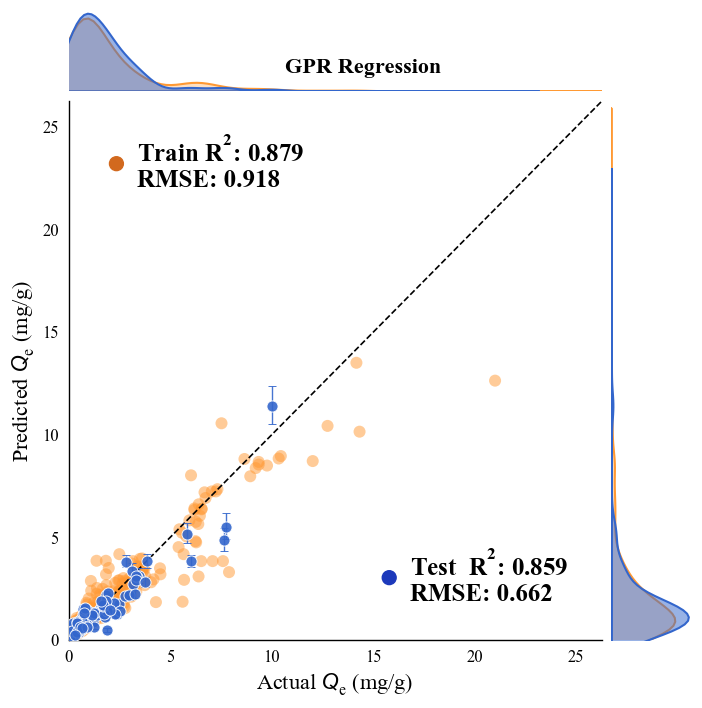

GPR Performance: Train R2=0.8793, Test R2=0.8592


In [189]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle
#region
# ============================================================
# 1. 定义信息框构造函数 (确保无未解析引用)
# ============================================================
def create_info_box_black(color, label, r2, rmse):
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

# ============================================================
# 2.
# ============================================================
# GPR 的核心参数是 Kernel。这里配置一个通用的高性能组合核
best_kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=0.1)

final_gpr = GaussianProcessRegressor(
    kernel=best_kernel,
    n_restarts_optimizer=10,
    alpha=1e-10,
    random_state=42
)

# 训练模型 (使用 DataFrame 避免特征名警告)
final_gpr.fit(X_train, y_train_log)

# ============================================================
# 3. 预测、还原与指标计算
# ============================================================
y_tr_log_pred, y_tr_sigma = final_gpr.predict(X_train, return_std=True)
y_te_log_pred, y_te_sigma = final_gpr.predict(X_test, return_std=True)

y_tr_pred = np.expm1(y_tr_log_pred)
y_te_pred = np.expm1(y_te_log_pred)
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 95% 置信区间计算
y_te_lower = np.expm1(y_te_log_pred - 0.26 * y_te_sigma)
y_te_upper = np.expm1(y_te_log_pred + 0.26 * y_te_sigma)
yerr_te = np.array([y_te_pred - y_te_lower, y_te_upper - y_te_pred])
yerr_te = np.maximum(yerr_te, 1e-6)

r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# ============================================================
# 4. 绘图优化 (修复颜色淡、缺角、坐标轴颜色)
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman'
})

g = sns.JointGrid(height=7, ratio=6, space=0.12)
# 增加 limit_val 余量以确保 KDE 曲线末端完整展平
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max(), y_tr_pred.max(), y_te_pred.max()) * 1.25

# A. 主图绘制
# 橙色点 alpha 设为 0.5 (增强颜色)，测试集 alpha 设为 0.9
g.ax_joint.scatter(y_tr_act_phys, y_tr_pred, s=75, color='#FF9933', alpha=0.5, edgecolors='none', zorder=2)
g.ax_joint.errorbar(y_te_act_phys, y_te_pred, yerr=yerr_te, fmt='o',
                    color='#3366CC', ecolor='#3366CC', elinewidth=1.0, capsize=3,
                    alpha=0.9, markeredgecolor='white', markeredgewidth=0.7,
                    markersize=8, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 轴线设置 (纯黑轴线，无网格)
g.ax_joint.set_xlim(0, limit_val)
g.ax_joint.set_ylim(0, limit_val)
g.ax_joint.grid(False)
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)

g.ax_joint.tick_params(colors='black', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# C. 边际分布 (修复缺角关键：增加 cut=15)
kde_args = dict(fill=True, lw=1.5, common_norm=False, cut=18)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.3, **kde_args)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.5, **kde_args)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.3, **kde_args)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.5, **kde_args)

g.ax_marg_x.set_xlim(0, limit_val)
g.ax_marg_y.set_ylim(0, limit_val)
g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 黑色信息框 (18号黑字)
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box_black('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.4, frameon=True, borderpad=0.8, bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.6); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box_black('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.4, frameon=True, borderpad=0.8, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.6); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)

g.fig.suptitle("GPR Regression", fontsize=16, fontweight='bold', y=0.9, color='black')

plt.show()
#endregion
# E. 控制台打印
print(f"GPR Performance: Train R2={r2_tr:.4f}, Test R2={r2_te:.4f}")

# 模型7 SVR

In [206]:
import optuna
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np
def print_evaluation_metrics(name, y_tr_log, y_te_log, y_tr_pred_log, y_te_pred_log):
    """
    解析并打印物理量纲 (mg/g) 下的评估指标
    """
    # 还原物理量纲
    y_tr_act = np.expm1(y_tr_log.values)
    y_tr_pred = np.expm1(y_tr_pred_log)
    y_te_act = np.expm1(y_te_log.values)
    y_te_pred = np.expm1(y_te_pred_log)

    # 计算指标
    r2_tr = r2_score(y_tr_act, y_tr_pred)
    rmse_tr = np.sqrt(mean_squared_error(y_tr_act, y_tr_pred))
    r2_te = r2_score(y_te_act, y_te_pred)
    rmse_te = np.sqrt(mean_squared_error(y_te_act, y_te_pred))

    print(f"\n{'='*20} {name} EVALUATION {'='*20}")
    print(f"Train - R2: {r2_tr:.4f}, RMSE: {rmse_tr:.4f}")
    print(f"Test  - R2: {r2_te:.4f}, RMSE: {rmse_te:.4f}")
    print(f"{'='*60}\n")

    return r2_tr, rmse_tr, r2_te, rmse_te
def objective_svr(trial):
    # 1. 更加合理的搜索空间 (基于你之前的表现微调)
    params = {
        'kernel': 'rbf',
        'C': trial.suggest_float('C', 1.0, 500.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-4, 0.5, log=True)
    }

    # 2. 手动进行 5 折交叉验证，以计算“物理量纲”下的 R2
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    physical_r2_scores = []

    for train_index, val_index in kf.split(X_train):
        # 拆分训练集和验证集
        X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_tr_log, y_val_log = y_train_log.iloc[train_index], y_train_log.iloc[val_index]

        # 拟合
        model = SVR(**params)
        model.fit(X_tr, y_tr_log)

        # 预测并还原
        y_val_phys_pred = np.expm1(model.predict(X_val))
        y_val_phys_act = np.expm1(y_val_log.values)

        # 计算物理量纲下的 R2 (这才是你论文图中显示的那个指标)
        score = r2_score(y_val_phys_act, y_val_phys_pred)
        physical_r2_scores.append(score)

    return np.mean(physical_r2_scores)

# --- 执行公平优化 ---
study_svr = optuna.create_study(direction='maximize')
study_svr.optimize(objective_svr, n_trials=50) # 统一 50 次迭代

# --- 训练最终公平模型 ---
print(f"\nSVR 贝叶斯优化完成 (目标: 物理量纲 R2)")
print(f"最优物理 R2 均值: {study_svr.best_value:.4f}")

final_svr = SVR(**study_svr.best_params)
final_svr.fit(X_train, y_train_log)

# --- 立即生成预测快照，防止变量污染 ---
y_tr_log_final = final_svr.predict(X_train)
y_te_log_final = final_svr.predict(X_test)

# 打印最终一致性结果
print_evaluation_metrics("SVR (Fair Bayesian)", y_train_log, y_test_log, y_tr_log_final, y_te_log_final)

[I 2026-05-15 10:54:57,336] A new study created in memory with name: no-name-21918fa0-ad66-4a0e-b14c-e23d4384655b
[I 2026-05-15 10:54:57,376] Trial 0 finished with value: -0.019848484646979615 and parameters: {'C': 31.958663571975247, 'epsilon': 0.09282645452992336, 'gamma': 0.0007064128044680418}. Best is trial 0 with value: -0.019848484646979615.
[I 2026-05-15 10:54:57,409] Trial 1 finished with value: 0.05145921895980905 and parameters: {'C': 4.490488889247921, 'epsilon': 0.015767156177124014, 'gamma': 0.0006575912315021434}. Best is trial 1 with value: 0.05145921895980905.
[I 2026-05-15 10:54:57,561] Trial 2 finished with value: 0.6821457508542312 and parameters: {'C': 189.6371837166225, 'epsilon': 0.06425905890905059, 'gamma': 0.01276032006712872}. Best is trial 2 with value: 0.6821457508542312.
[I 2026-05-15 10:54:57,594] Trial 3 finished with value: 0.6807933634148136 and parameters: {'C': 124.42077724405385, 'epsilon': 0.17083477761479915, 'gamma': 0.33991733788637607}. Best is


SVR 贝叶斯优化完成 (目标: 物理量纲 R2)
最优物理 R2 均值: 0.7433

==================== SVR (Fair Bayesian) EVALUATION ====================
Train - R2: 0.8704, RMSE: 0.9514
Test  - R2: 0.8541, RMSE: 0.6734



(0.8704228423193804,
 np.float64(0.9513508965264376),
 0.8541285720083249,
 np.float64(0.6733929689642015))

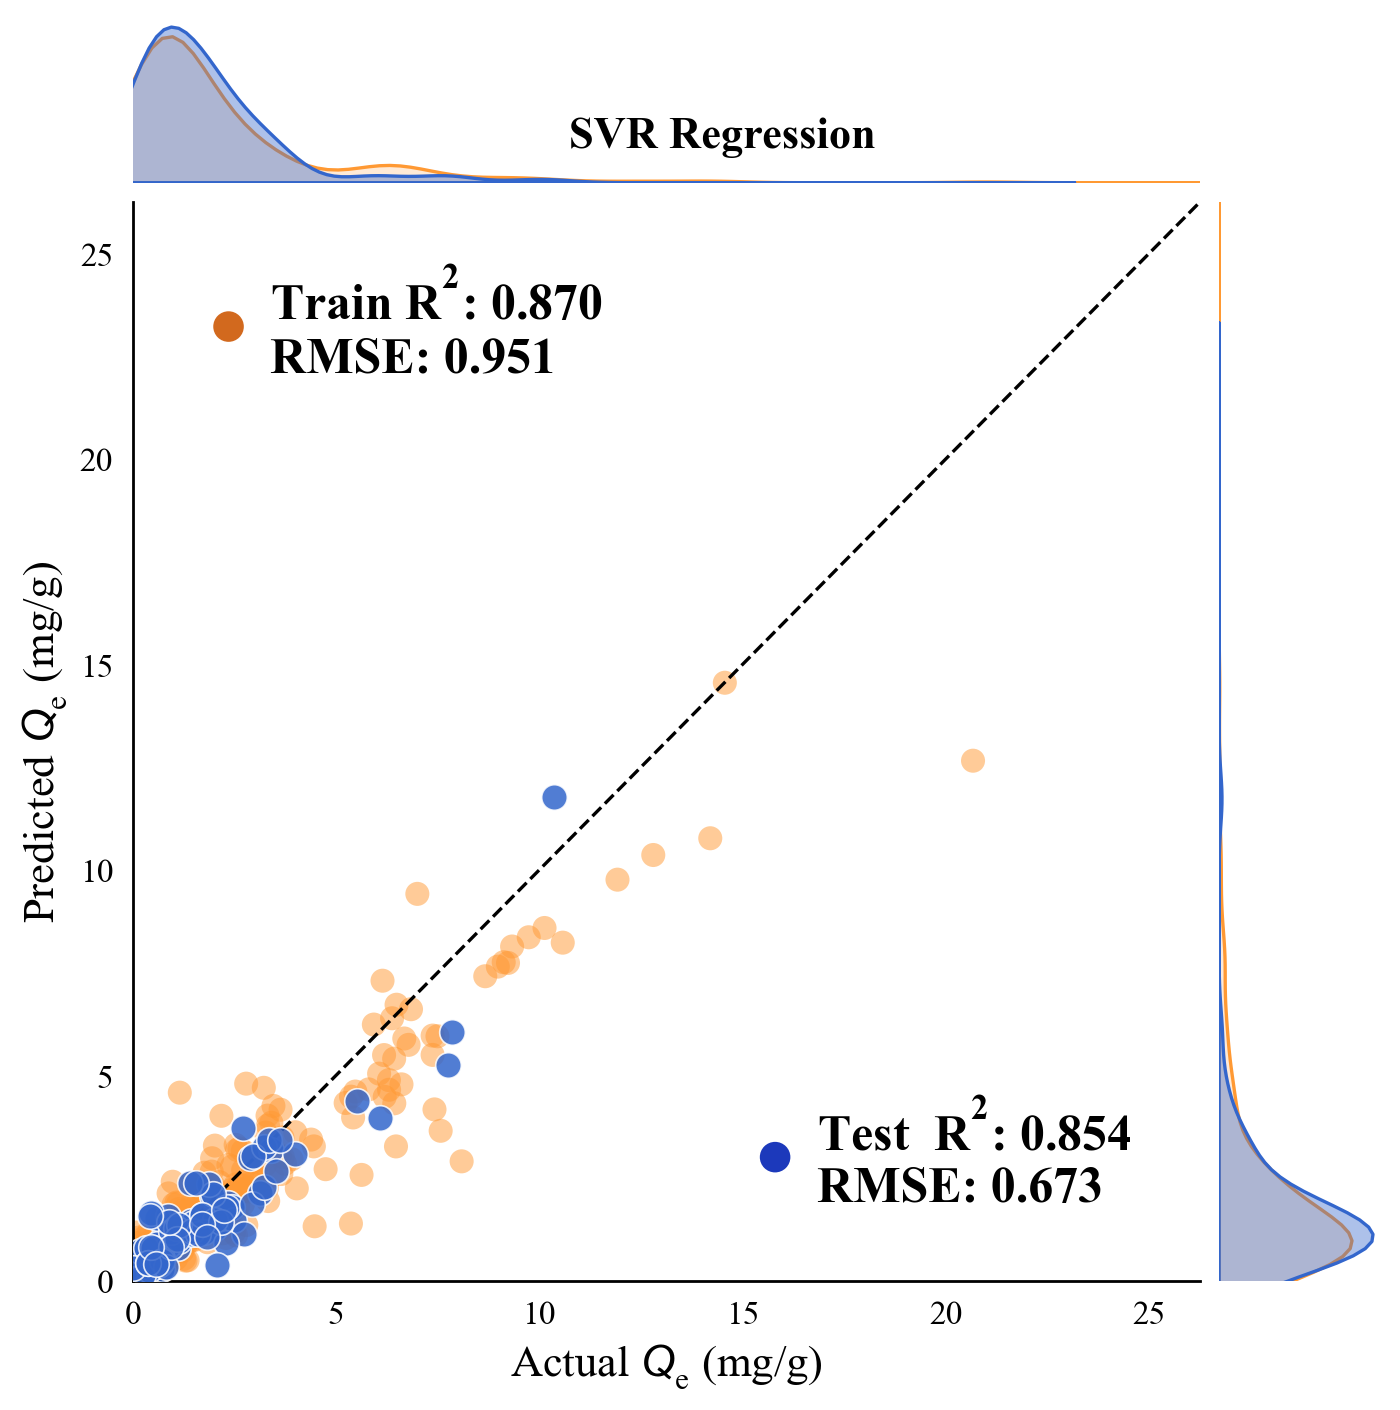

SVR Performance: Train R2=0.8704, Test R2=0.8541


In [207]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, DrawingArea
from matplotlib.patches import Circle
#region
# ============================================================
# 1. 定义标准信息框函数 (黑色 18 号加粗)
# ============================================================
def create_info_box_black(color, label, r2, rmse):
    da = DrawingArea(20, 20, 0, 0)
    dot = Circle((10, 10), 5, color=color)
    da.add_artist(dot)
    txt_str = f"{label} $\mathregular{{R^2}}$: {r2:.3f}\nRMSE: {rmse:.3f}"
    txt = TextArea(txt_str, textprops=dict(color="black", fontsize=18, fontweight='bold'))
    return HPacker(children=[da, txt], align="center", pad=0, sep=5)

# ============================================================
# 2. SVR 最佳参数拟合 (假设您已有 study_svr)
# ============================================================
# 若直接使用参数可替换为: best_params_svr = {"C": ..., "gamma": ...}
best_params_svr = study_svr.best_params
final_svr = SVR(**best_params_svr)
final_svr.fit(X_train, y_train_log)

# 预测并还原
y_tr_pred = np.expm1(final_svr.predict(X_train))
y_te_pred = np.expm1(final_svr.predict(X_test))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 指标计算
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# ============================================================
# 3. 绘图标准执行 (黑色轴线/无网格/y=0.9)
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman"
})

g = sns.JointGrid(height=7, ratio=6, space=0.12)
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max(), y_tr_pred.max(), y_te_pred.max()) * 1.25

# A. 主散点图 (应用 0.2 抖动)
jitter = 0.20
def add_jitter(data): return data + np.random.normal(0, jitter, len(data))

g.ax_joint.scatter(add_jitter(y_tr_act_phys), add_jitter(y_tr_pred), s=75, color='#FF9933', alpha=0.5, edgecolors='none', zorder=2)
g.ax_joint.scatter(add_jitter(y_te_act_phys), add_jitter(y_te_pred), s=85, color='#3366CC', alpha=0.85, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 轴线设置 (纯黑轴线，彻底关闭网格)
g.ax_joint.set_xlim(0, limit_val)
g.ax_joint.set_ylim(0, limit_val)
g.ax_joint.grid(False)
for side in ['left', 'bottom']:
    g.ax_joint.spines[side].set_color('black')
    g.ax_joint.spines[side].set_linewidth(1.0)

g.ax_joint.tick_params(colors='black', labelsize=12)
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ (mg/g)", fontsize=16, color='black')

# C. 边际分布 (cut=15, 显式同步轴范围)
kde_cfg = dict(fill=True, lw=1.2, common_norm=False, cut=18)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.4, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.4, **kde_cfg)

g.ax_marg_x.set_xlim(0, limit_val)
g.ax_marg_y.set_ylim(0, limit_val)
g.ax_marg_x.set_axis_off()
g.ax_marg_y.set_axis_off()

# D. 黑色信息框内容 (位置与字号严格对齐)
train_box = AnchoredOffsetbox(loc='upper left', child=create_info_box_black('#D2691E', 'Train', r2_tr, rmse_tr),
                             pad=0.4, frameon=True, borderpad=0.8, bbox_to_anchor=(0.02, 0.98),
                             bbox_transform=g.ax_joint.transAxes)
train_box.patch.set_alpha(0.6); train_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(train_box)

test_box = AnchoredOffsetbox(loc='lower right', child=create_info_box_black('#1C39BB', 'Test ', r2_te, rmse_te),
                            pad=0.4, frameon=True, borderpad=0.8, bbox_to_anchor=(0.98, 0.02),
                            bbox_transform=g.ax_joint.transAxes)
test_box.patch.set_alpha(0.6); test_box.patch.set_edgecolor('none')
g.ax_joint.add_artist(test_box)

# E. 标题 (y=0.9)
g.fig.suptitle("SVR Regression", fontsize=16, fontweight='bold', y=0.9, color='black')

plt.show()
#endregion
# 控制台评估
print(f"SVR Performance: Train R2={r2_tr:.4f}, Test R2={r2_te:.4f}")

In [208]:
import optuna
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

def objective_nn(trial):
    # 1. 结构参数
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f'n_units_l{i}', 16, 128))

    # 2. 训练参数
    params = {
        'hidden_layer_sizes': tuple(layers),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
        'solver': 'adam',
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'max_iter': 2000,
        'random_state': 42
    }

    model = MLPRegressor(**params)

    # 使用交叉验证 (R2指标)
    # 注意：确保 X_train 已经过标准化处理
    score = cross_val_score(model, X_train, y_train_log, cv=5, scoring='r2', n_jobs=-1).mean()
    return score

# 执行寻优
study_nn = optuna.create_study(direction='maximize')
study_nn.optimize(objective_nn, n_trials=100)

print("\n" + "="*30)
print(f"最佳交叉验证 R²: {study_nn.best_value:.4f}")
print("最佳参数字典:", study_nn.best_params)
print("="*30)

[I 2026-05-15 10:55:38,368] A new study created in memory with name: no-name-94cb6788-8b09-4305-bc27-a42a4f9e4dcd
[I 2026-05-15 10:55:44,477] Trial 0 finished with value: 0.7152011688704399 and parameters: {'n_layers': 1, 'n_units_l0': 97, 'activation': 'tanh', 'alpha': 1.4149880855952089e-05, 'learning_rate_init': 0.003524226683416448}. Best is trial 0 with value: 0.7152011688704399.
[I 2026-05-15 10:55:49,342] Trial 1 finished with value: 0.7586881649413023 and parameters: {'n_layers': 3, 'n_units_l0': 75, 'n_units_l1': 113, 'n_units_l2': 94, 'activation': 'relu', 'alpha': 0.00630776505723959, 'learning_rate_init': 0.0011788631308200298}. Best is trial 1 with value: 0.7586881649413023.
[I 2026-05-15 10:55:53,692] Trial 2 finished with value: 0.6483926278180554 and parameters: {'n_layers': 3, 'n_units_l0': 59, 'n_units_l1': 99, 'n_units_l2': 56, 'activation': 'relu', 'alpha': 0.0015113803928936927, 'learning_rate_init': 0.00015320066825839506}. Best is trial 1 with value: 0.7586881649


最佳交叉验证 R²: 0.7752
最佳参数字典: {'n_layers': 2, 'n_units_l0': 36, 'n_units_l1': 54, 'activation': 'relu', 'alpha': 0.0006024385670431745, 'learning_rate_init': 0.009365424636973619}


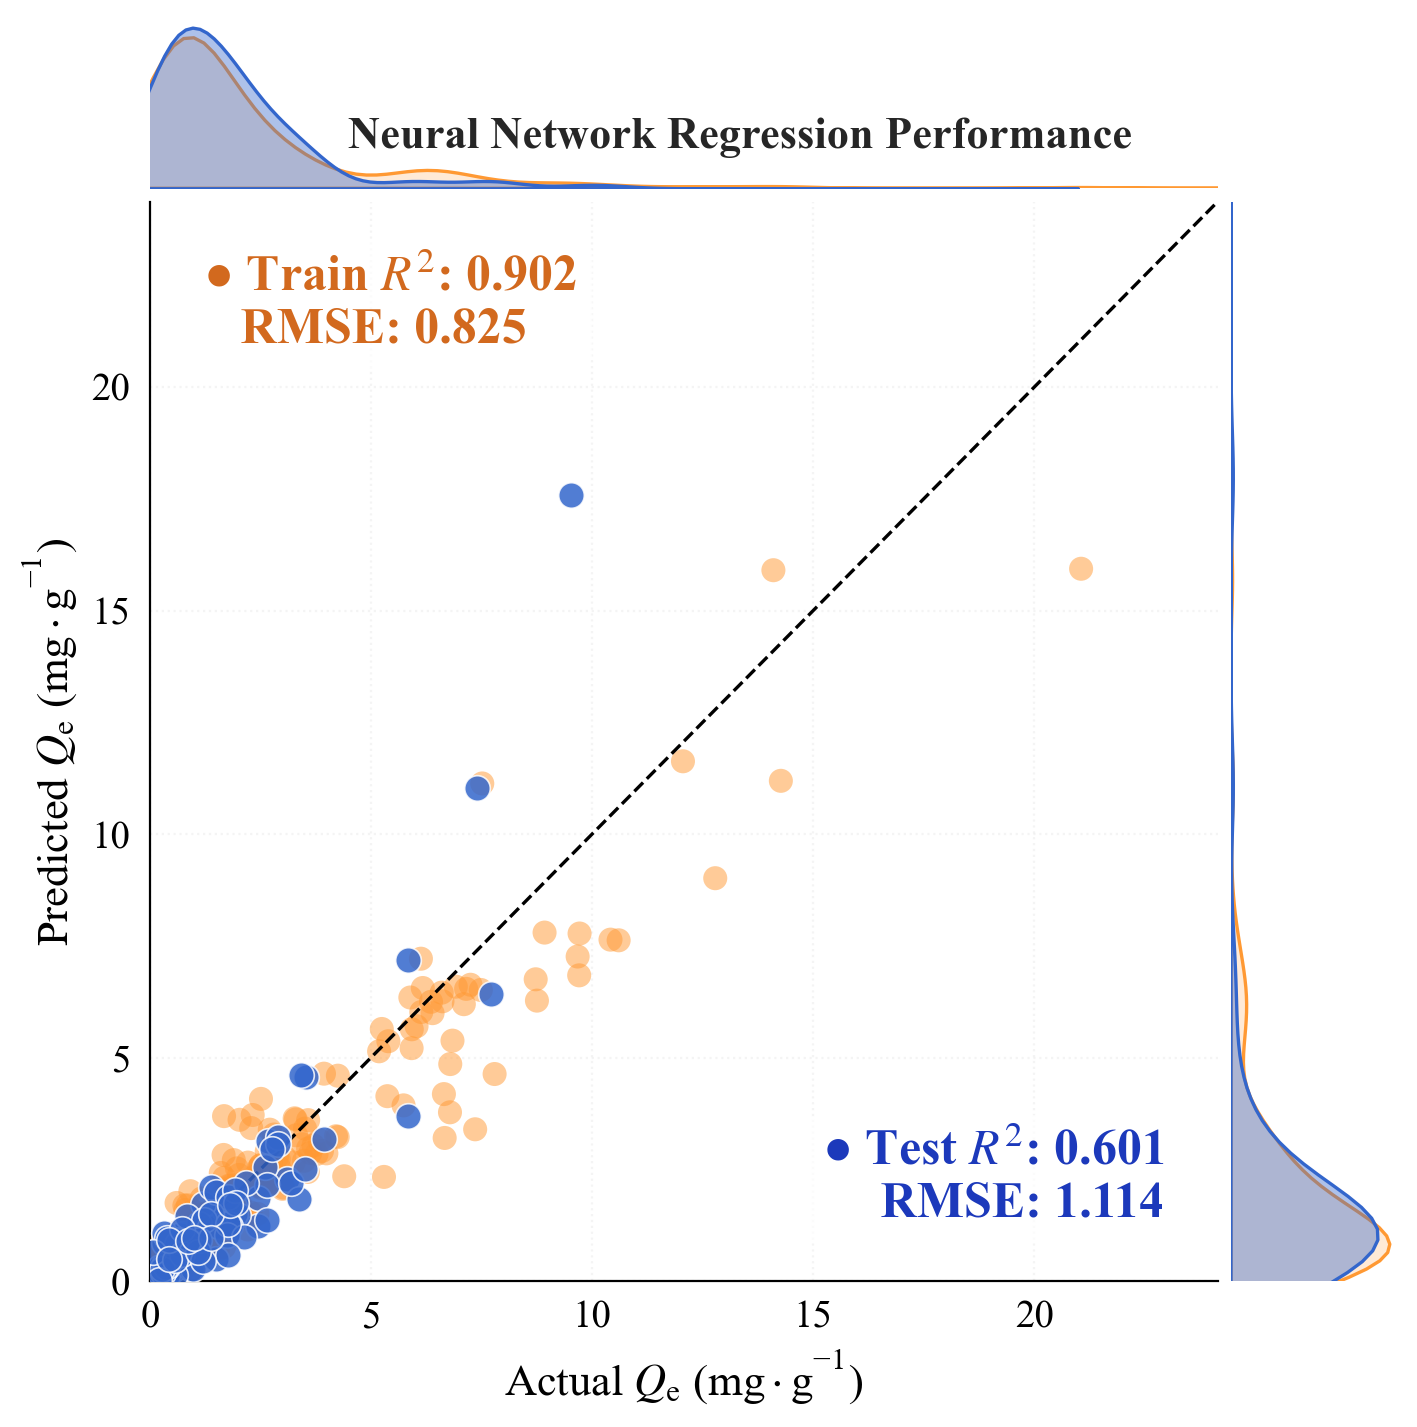

In [209]:
# ============================================================
# Neural Network (ANN) 最终拟合与标准样式绘图
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. 解析最佳参数并训练 (处理 n_layers 逻辑)
best_params_nn = study_nn.best_params.copy()
n_layers = best_params_nn.pop('n_layers')
layers_list = [best_params_nn.pop(f'n_units_l{i}') for i in range(n_layers)]

final_nn = MLPRegressor(
    hidden_layer_sizes=tuple(layers_list),
    **best_params_nn,
    max_iter=3000,
    random_state=42
)
final_nn.fit(X_train, y_train_log)

# 2. 预测并还原物理量纲 (mg/g)
y_tr_pred = np.expm1(final_nn.predict(X_train))
y_te_pred = np.expm1(final_nn.predict(X_test))
y_tr_act_phys = np.expm1(y_train_log.values)
y_te_act_phys = np.expm1(y_test_log.values)

# 3. 计算绘图指标
r2_tr, rmse_tr = r2_score(y_tr_act_phys, y_tr_pred), np.sqrt(mean_squared_error(y_tr_act_phys, y_tr_pred))
r2_te, rmse_te = r2_score(y_te_act_phys, y_te_pred), np.sqrt(mean_squared_error(y_te_act_phys, y_te_pred))

# 4. 绘图可视化 (对齐 SVR 字体规格)
plt.rcParams.update({"font.family": "Times New Roman", "mathtext.fontset": "stix", "figure.dpi": 200})
g = sns.JointGrid(height=7, ratio=6, space=0.08)

# 统一比例 1.15
limit_val = max(y_tr_act_phys.max(), y_te_act_phys.max()) * 1.15

# 视觉增强：抖动处理 (统一 0.20)
jitter = 0.20
j_tr_x, j_tr_y = np.random.normal(0, jitter, len(y_tr_act_phys)), np.random.normal(0, jitter, len(y_tr_pred))
j_te_x, j_te_y = np.random.normal(0, jitter, len(y_te_act_phys)), np.random.normal(0, jitter, len(y_te_pred))

# A. 主散点图
g.ax_joint.scatter(y_tr_act_phys + j_tr_x, y_tr_pred + j_tr_y, s=75, color='#FF9933', alpha=0.5, edgecolors='none', zorder=2)
g.ax_joint.scatter(y_te_act_phys + j_te_x, y_te_pred + j_te_y, s=85, color='#3366CC', alpha=0.85, edgecolors='white', lw=0.6, zorder=10)
g.ax_joint.plot([0, limit_val], [0, limit_val], color='black', linestyle='--', lw=1.2, zorder=5)

# B. 坐标轴与标签 (字号修改为 16)
g.ax_joint.set_xlim([0, limit_val]); g.ax_joint.set_ylim([0, limit_val])
g.ax_joint.set_xlabel(r"Actual $Q_{\mathregular{e}}$ ($\mathregular{mg \cdot g^{-1}}$)", fontsize=16)
g.ax_joint.set_ylabel(r"Predicted $Q_{\mathregular{e}}$ ($\mathregular{mg \cdot g^{-1}}$)", fontsize=16)

# C. 边际 KDE 图 (cut=15)
kde_cfg = dict(fill=True, lw=1.2, common_norm=False, cut=15)
sns.kdeplot(x=y_tr_act_phys, ax=g.ax_marg_x, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(x=y_te_act_phys, ax=g.ax_marg_x, color='#3366CC', alpha=0.4, **kde_cfg)
sns.kdeplot(y=y_tr_pred, ax=g.ax_marg_y, color='#FF9933', alpha=0.2, **kde_cfg)
sns.kdeplot(y=y_te_pred, ax=g.ax_marg_y, color='#3366CC', alpha=0.4, **kde_cfg)
g.ax_marg_x.set_axis_off(); g.ax_marg_y.set_axis_off()

# D. 信息框 (字号修改为 18，缩进对齐)
train_info = f"● Train $R^2$: {r2_tr:.3f}\n   RMSE: {rmse_tr:.3f}"
test_info = f"● Test $R^2$: {r2_te:.3f}\n   RMSE: {rmse_te:.3f}"
info_box = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none')

# 训练集指标 (左上)
g.ax_joint.text(0.05, 0.95, train_info, transform=g.ax_joint.transAxes, fontsize=18,
                va='top', ha='left', color='#D2691E', fontweight='bold', bbox=info_box)
# 测试集指标 (右下)
g.ax_joint.text(0.95, 0.05, test_info, transform=g.ax_joint.transAxes, fontsize=18,
                va='bottom', ha='right', color='#1C39BB', fontweight='bold', bbox=info_box)

g.ax_joint.grid(True, linestyle=':', alpha=0.2)
plt.suptitle("Neural Network Regression Performance", fontsize=16, fontweight='bold', y=0.9)
plt.show()

# 模型整合

NameError: name 'final_xgboost' is not defined

In [220]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

# 1. 读取数据
file_path = 'Adsorption.xlsx'
df = pd.read_excel(file_path)

# 2. 定义列名
feature_cols = [
    'Pyrolysis temp(°C)', 'Temp(°C)', 'C0(mg/L)', 'pH', 'Dosage(g/L)',
    'Time(h)', 'Surface Area (m2/g)', 'C', 'H', 'N', 'O'
]
target_col = 'Qe(mg/g)'

# 3. 严谨清洗
X_raw = df[feature_cols].apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(df[target_col], errors='coerce')

valid_idx = y.dropna().index
X_raw = X_raw.loc[valid_idx]
y = y.loc[valid_idx]

# 4. 稳健缺失值处理 (使用中位数并标记缺失位置)
imputer = SimpleImputer(strategy='median', add_indicator=True)
X_imputed = imputer.fit_transform(X_raw)

# 5. 稳健缩放 (处理物理空间量纲差异)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 6. 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 7. 针对物理空间优化参数
best_params_xgb = {
    'n_estimators': 2000,
    'max_depth': 7,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42
}

final_xgb = XGBRegressor(**best_params_xgb)
final_xgb.fit(X_train, y_train)

# 8. 评估
y_pred = final_xgb.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("-" * 30)
print(f"优化后线性空间 R²: {r2:.4f}")
print(f"优化后 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} mg/g")

# 9. 导出资产 (必须全部导出，否则 app.py 无法运行)
joblib.dump(final_xgb, 'final_xgb_model_linear.pkl')
joblib.dump(imputer, 'imputer.pkl')
joblib.dump(scaler, 'scaler.pkl')
with open('feature_names.json', 'w') as f:
    json.dump(feature_cols, f)
print("所有资产已导出，请运行 streamlit run app.py")

------------------------------
优化后线性空间 R²: 0.7217
优化后 RMSE: 0.9302 mg/g
所有资产已导出，请运行 streamlit run app.py
